# Weak-lensing galaxy shape catalogue validation

### Local calibration

Version 06/05/2021

Includes
- PSF residuals
- PSF to galaxy shapes leakage
- Additive shear bias
- Convergence E- and B-modes
- Cluster lensing

## Set-up

In [1]:
import sys
import os
import numpy as np

import shapepipe
from shapepipe.utilities.canfar import download

ImportError: cannot import name 'download' from 'shapepipe.utilities.canfar' (/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/shapepipe-0.0.2-py3.7.egg/shapepipe/utilities/canfar.py)

In [109]:
from sp_validation.basic import *
from sp_validation.plot_style import *

from scipy import ndimage as ndi
from scipy import signal

from lenspack import peaks
from lenspack.peaks import find_peaks2d
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import pandas as pd

In [3]:
# The following commands will be replaced by import instructions, once the sp_validation scripts are stable

#sp_val = '{}/astro/repositories/github/sp_validation/sp_validation'.format(os.environ['HOME'])
sp_val = '{}/sp_validation/sp_validation'.format(os.environ['HOME'])

for sc in ['survey', 'params', 'io']:
    script = os.path.join(sp_val, sc)
    %run $script

### Load parameters

### Output files and directories

In [4]:
make_out_dirs(plot_dir, plot_subdirs, verbose=verbose)
stats_file = open_stats_file(plot_dir, stats_file_name)

## Load data

### Load merged (final) galaxy catalogue

In [5]:
dd = np.load(galaxy_cat_path, mmap_mode=None)

#### Print some quantities to check nothing obvious is wrong with catalogue

In [6]:
# Print all column names
print('Galaxy cat column names:')
print(dd.dtype.names)
print()

# Mean ellipticity looks reasonable, no `nan`?
print('Mean gal ellipticity =', dd['NGMIX_ELL_NOSHEAR'].mean(axis=0))

# Total number of objects
n_tot_dd = len(dd)
print('Total number of objects = {} = {:.2f} Mio'.format(n_tot_dd, n_tot_dd / 1e6))

Galaxy cat column names:
('XWIN_WORLD', 'YWIN_WORLD', 'TILE_ID', 'FLAGS', 'IMAFLAGS_ISO', 'NGMIX_MCAL_FLAGS', 'NGMIX_ELL_PSFo_NOSHEAR', 'GALSIM_PSF_ELL_ORIGINAL_PSF', 'SPREAD_CLASS', 'SPREAD_MODEL', 'SPREADERR_MODEL', 'N_EPOCH', 'NGMIX_N_EPOCH', 'NGMIX_ELL_1M', 'NGMIX_ELL_1P', 'NGMIX_ELL_2M', 'NGMIX_ELL_2P', 'NGMIX_ELL_NOSHEAR', 'NGMIX_ELL_ERR_NOSHEAR', 'NGMIX_FLAGS_1M', 'NGMIX_FLAGS_1P', 'NGMIX_FLAGS_2M', 'NGMIX_FLAGS_2P', 'NGMIX_FLAGS_NOSHEAR', 'NGMIX_T_1M', 'NGMIX_T_1P', 'NGMIX_T_2M', 'NGMIX_T_2P', 'NGMIX_T_NOSHEAR', 'NGMIX_T_ERR_1M', 'NGMIX_T_ERR_1P', 'NGMIX_T_ERR_2M', 'NGMIX_T_ERR_2P', 'NGMIX_T_ERR_NOSHEAR', 'NGMIX_Tpsf_1M', 'NGMIX_Tpsf_1P', 'NGMIX_Tpsf_2M', 'NGMIX_Tpsf_2P', 'NGMIX_Tpsf_NOSHEAR', 'NGMIX_FLUX_1M', 'NGMIX_FLUX_1P', 'NGMIX_FLUX_2M', 'NGMIX_FLUX_2P', 'NGMIX_FLUX_NOSHEAR', 'NGMIX_FLUX_ERR_1M', 'NGMIX_FLUX_ERR_1P', 'NGMIX_FLUX_ERR_2M', 'NGMIX_FLUX_ERR_2P', 'NGMIX_FLUX_ERR_NOSHEAR', 'GALSIM_GAL_ELL_1M', 'GALSIM_GAL_ELL_1P', 'GALSIM_GAL_ELL_2M', 'GALSIM_GAL_ELL_2P', 'GALS

#### Survey area and potential missing tiles
The approximate observed area is the number of tiles $\times$ 0.25 deg$^2$ (ignoring overlaps and masking).

In [7]:
area_deg2, area_amin2, tile_IDs = get_area(dd, area_tile, verbose=verbose)

Number of tiles found in galaxy catalogue = 214
Area [deg^2] = 53.5


Identify missing tiles by comparing tile ID from catalogue to external input tile ID file.

In [8]:
n_found, n_missing = missing_tiles(tile_IDs, path_tile_ID, path_missing_ID, verbose=verbose)

0/214 = 0% tiles missing


### Load star catalogue

In [9]:
d_star = fits.getdata('./psf_validation_merged/psf_cat_full.fits', 1)

In [10]:
print('Star cat column names:')
print(d_star.dtype.names)
print()

print('Mean PSF ellipticity = ({:.3g}, {:.3g})'
      ''.format(np.mean(d_star['E1_PSF_HSM']), np.mean(d_star['E2_PSF_HSM'])))

print('Number of objects = ', len(d_star))

Star cat column names:
('X', 'Y', 'RA', 'DEC', 'E1_PSF_HSM', 'E2_PSF_HSM', 'SIGMA_PSF_HSM', 'E1_STAR_HSM', 'E2_STAR_HSM', 'SIGMA_STAR_HSM', 'FLAG_PSF_HSM', 'FLAG_STAR_HSM', 'MAG', 'SNR', 'ACCEPTED', 'CCD_NB')

Mean PSF ellipticity = (0.0243, 0.00937)
Number of objects =  90408


# Data

## Matching of star catalogues
Match the star catalogue `d_star` (selected on individual exposures using size-magnitude diagram) to the stars identified on tiles by shape measurement algorithms.

This is mainly for testing, this match will not be used later.

### Match to all objects

In [11]:
# Filter stars outside footprint for efficiency
mask_area_tiles = get_mask_footprint_P3(d_star['RA'], d_star['DEC'])

# Maximum distance in degrees for matching
thresh = 0.0002

# Match stars from exposure (PSF) catalogue to total catalogue
ind_star = match_stars2(dd['XWIN_WORLD'], dd['YWIN_WORLD'], d_star['RA'][mask_area_tiles],
                        d_star['DEC'][mask_area_tiles], thresh=thresh)
msg = 'Number of matched stars from exposures to total catalogue = {} = {:.1f}%' \
      ''.format(len(ind_star), len(ind_star) / len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file, verbose=verbose)

# Testing
ind_star_test = match_stars2(dd['XWIN_WORLD'], dd['YWIN_WORLD'], d_star['RA'], d_star['DEC'], thresh=thresh)
print('[ Check: #stars without removing tiles outside footprint = {} ]'.format(len(ind_star_test)))

# Remove stars matched to more than one target object
ind_star = np.array(list(set(ind_star)))

msg = 'Number of matched stars after removing multuple matches = {} = {:.1f}%' \
      ''.format(len(ind_star), len(ind_star) / len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file)

Number of matched stars from exposures to total catalogue = 64997 = 71.9%
[ Check: #stars without removing tiles outside footprint = 64997 ]


#### Refine: match to ngmix star sample

In [12]:
# Flags to indicate ngmix star sample
m_star_ngmix = (dd['FLAGS'][ind_star] == 0) & \
               (dd['IMAFLAGS_ISO'][ind_star] == 0) & \
               (dd['NGMIX_MCAL_FLAGS'][ind_star] == 0) & \
               (dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][ind_star] != -10)

msg = 'Number of stars matched to ngmix star sample = {} = {:.1f}%' \
      ''.format(len(dd['FLAGS'][ind_star][m_star_ngmix]),
                len(dd['FLAGS'][ind_star][m_star_ngmix]) / len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file, verbose=verbose)

g_star_psf_ngmix = np.array([dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][ind_star][m_star_ngmix], dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][ind_star][m_star_ngmix]])
ra_star_ngmix = dd['XWIN_WORLD'][ind_star][m_star_ngmix]
dec_star_ngmix = dd['YWIN_WORLD'][ind_star][m_star_ngmix]

Number of stars matched to ngmix star sample = 50293 = 55.6%


#### Objects with invalid PSF

In [13]:
n_all = len(dd)

w = dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0] == -10
n_inv_psf = len(np.where(w)[0])
print('Invalid PSF shear found for {}/{} = {:.1g}% objects'.format(n_inv_psf, n_all, n_inv_psf / n_all))

w = dd['NGMIX_ELL_NOSHEAR'][:,0] == -10
n_inv_gal = len(np.where(w)[0])
print('Invalid galaxy shear found for {}/{} = {:.1g}% objects'
      ''.format(n_inv_gal, n_all, n_inv_gal / n_all))

Invalid PSF shear found for 158639/5367032 = 0.03% objects
Invalid galaxy shear found for 158639/5367032 = 0.03% objects


#### Star galsim

In [14]:
msg = "Number of star matched : {}  ( {:.2f}% )".format(len(ind_star), len(ind_star)/len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file, verbose=verbose)

m_star_galsim = (dd['FLAGS'][ind_star] == 0) & (dd['IMAFLAGS_ISO'][ind_star] == 0) \
          & (dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][ind_star] != -10)

msg = "Number of star after removing repetition : {}".format(len(dd['FLAGS'][ind_star][m_star_galsim]))
print_stats(msg, stats_file, verbose=verbose)

g_star_psf_galsim = np.array([dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][ind_star][m_star_galsim], dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,1][ind_star][m_star_galsim]])
ra_star_galsim = dd['XWIN_WORLD'][ind_star][m_star_galsim]
dec_star_galsim = dd['YWIN_WORLD'][ind_star][m_star_galsim]

msg = "Number of star matched : {}  ( {:.2f}% )\n".format(len(ind_star), len(ind_star)/len(d_star['RA'][mask_area_tiles])*100)
print_stats(msg, stats_file, verbose=verbose)

Number of star matched : 54486  ( 60.27% )
Number of star after removing repetition : 46486
Number of star matched : 54486  ( 60.27% )



#### Stat stars ngmix

In [15]:
tot_star = len(ra_star_ngmix)
tot_as_star = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_ngmix] == 0)[0])
tot_as_gal = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_ngmix] == 1)[0])
tot_as_other = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_ngmix] == 2)[0])
print("Star (single_selection) as star (spread_model) : {:.3f}%".format(tot_as_star/tot_star*100))
print("Star (single_selection) as gal (spread_model) : {:.3f}%".format(tot_as_gal/tot_star*100))
print("Star (single_selection) as other (spread_model) : {:.3f}%".format(tot_as_other/tot_star*100))
stats_file.write("Star (single_selection) as star (spread_model) : {:.3f}%\n".format(tot_as_star/tot_star*100))
stats_file.write("Star (single_selection) as gal (spread_model) : {:.3f}%\n".format(tot_as_gal/tot_star*100))
dummy = stats_file.write("Star (single_selection) as other (spread_model) : {:.3f}%\n".format(tot_as_other/tot_star*100))

Star (single_selection) as star (spread_model) : 99.415%
Star (single_selection) as gal (spread_model) : 0.000%
Star (single_selection) as other (spread_model) : 0.585%


#### Stat stars galsim

In [16]:
tot_star = len(ra_star_galsim)
tot_as_star = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_galsim] == 0)[0])
tot_as_gal = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_galsim] == 1)[0])
tot_as_other = len(np.where(dd['SPREAD_CLASS'][ind_star][m_star_galsim] == 2)[0])
print("Star (single_selection) as star (spread_model) : {:.3f}%".format(tot_as_star/tot_star*100))
print("Star (single_selection) as gal (spread_model) : {:.3f}%".format(tot_as_gal/tot_star*100))
print("Star (single_selection) as other (spread_model) : {:.3f}%".format(tot_as_other/tot_star*100))
stats_file.write("Star (single_selection) as star (spread_model) : {:.3f}%\n".format(tot_as_star/tot_star*100))
stats_file.write("Star (single_selection) as gal (spread_model) : {:.3f}%\n".format(tot_as_gal/tot_star*100))
dummy = stats_file.write("Star (single_selection) as other (spread_model) : {:.3f}%\n".format(tot_as_other/tot_star*100))

Star (single_selection) as star (spread_model) : 99.692%
Star (single_selection) as gal (spread_model) : 0.000%
Star (single_selection) as other (spread_model) : 0.308%


### Select galaxies

#### Galxies ngmix

In [17]:
sm_classif = dd['SPREAD_MODEL']+2*dd['SPREADERR_MODEL']
m_gal_ngmix = \
    (sm_classif > 0.0035) \
    & (dd['SPREAD_MODEL'] > 0.) \
    & (dd['SPREAD_MODEL'] < 0.03) \
    & (dd['MAG_AUTO'] < 26) \
    & (dd['MAG_AUTO'] > 20) \
    & (dd['FLAGS'] == 0) \
    & (dd['IMAFLAGS_ISO'] == 0) \
    & (dd['NGMIX_MCAL_FLAGS'] == 0) \
    & (dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0] != -10) \
    & (dd['NGMIX_MOM_FAIL'] == 0) \
    & (dd['N_EPOCH'] > 0) \
    & (dd['NGMIX_N_EPOCH'] > 0)
print('Objects selected as galaxies = {}'.format(len(np.where(m_gal_ngmix)[0])))

Objects selected as galaxies = 3466497


In [18]:
print(len(dd))
a= dd['FLAGS'] == 0
len(dd[a])

5367032


4507655

#### Galaxies galsim

In [19]:
sm_classif = dd['SPREAD_MODEL']+2*dd['SPREADERR_MODEL']
#m_gal = (dd['SPREAD_CLASS'] == 1) & (dd['SPREAD_MODEL'] > 0.)  (dd['MAG_AUTO'] > 20)   ((dd['FLAGS'] == 0) | (dd['FLAGS'] == 2))
m_gal_galsim = (sm_classif > 0.0035) & (dd['SPREAD_MODEL'] > 0.) & (dd['SPREAD_MODEL'] < 0.03) \
        & (dd['MAG_AUTO'] < 26) & (dd['MAG_AUTO'] > 20) \
        & (dd['FLAGS'] == 0) & (dd['IMAFLAGS_ISO'] == 0) \
        & (dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0] != -10) \
        & (dd['N_EPOCH'] > 0)

### Compile metacal for galaxies  

Masking : Flags == 0   &   $\frac{T_{gal}}{T_{psf}}$ > 0.5   &   SNR > 10   &   SNR < 500

#### Ngmix

In [20]:
gal_metacal_ngmix = metacal(dd, m_gal_ngmix)

Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


In [21]:
g_ngmix = np.array([gal_metacal_ngmix.ns['g1'][gal_metacal_ngmix.mask_dict['ns']], gal_metacal_ngmix.ns['g2'][gal_metacal_ngmix.mask_dict['ns']]])
g_corr_ngmix = np.linalg.inv(gal_metacal_ngmix.R).dot(g_ngmix)
w_ngmix = gal_metacal_ngmix.ns['w'][gal_metacal_ngmix.mask_dict['ns']]
ra_ngmix = dd['XWIN_WORLD'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
dec_ngmix = dd['YWIN_WORLD'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
mag_ngmix = dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
snr_ngmix = dd['NGMIX_FLUX_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

In [22]:
R_shear_moy = np.mean(gal_metacal_ngmix.R_shear,2)
R_selec_moy = gal_metacal_ngmix.R_selection
R_selec_moy_std = gal_metacal_ngmix.R_selection_std
R_tot_moy = gal_metacal_ngmix.R

In [23]:
# PSF
Psf1 = dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
Psf2 = dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]
module_psf = np.sqrt(Psf1**2 + Psf2**2)

# Size gal
size_gal = dd['NGMIX_T_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

# N epoch
nepoch = dd['NGMIX_N_EPOCH'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

# Mag
mag = dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

# snr
snr_win = dd['SNR_WIN'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]

#### Local calibration

In [24]:
print('size ra',np.max(dd['XWIN_WORLD'])-np.min(dd['XWIN_WORLD']))
print('size dec',np.max(dd['YWIN_WORLD'])-np.min(dd['YWIN_WORLD']))

size ra 13.818141765163489
size dec 7.016595708623278


In [25]:
Nx = int(13.8*60/0.4)
Ny = int(7*60/0.4)
print(Nx,Ny)

2070 1050


In [26]:
x, y = radec2xy(np.mean(dd['XWIN_WORLD']), np.mean(dd['YWIN_WORLD']), dd['XWIN_WORLD'], dd['YWIN_WORLD'])

In [27]:
min_x = np.min(x)
max_x = np.max(x)
min_y = np.min(y)
max_y = np.max(y)

size_x = max_x - min_x
size_y = max_y - min_y

In [28]:
# Project (ra,dec) -> (x,y)
xx, yy = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), ra_ngmix, dec_ngmix)

In [29]:
def local_calib2(npix_x,npix_y):
    g1_final = np.array([])
    g2_final = np.array([])
    g1 = np.array([])
    g2 = np.array([])
    g1_final_dm = np.array([])
    g2_final_dm = np.array([])
    R_selec = np.zeros((2,2,npix_y,npix_x))
    R_shear = np.zeros((2,2,npix_y,npix_x))
    ra_ngmix2 = np.array([])
    dec_ngmix2 = np.array([])
    R_selec_std = np.zeros((2,2,npix_y,npix_x))
    
    ngal = bin2d(xx, yy, npix=(npix_x,npix_y))

    for i in range(npix_x):
        for j in range(npix_y):
            if(i==npix_x and j!=npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y < min_y + ((j+1)*size_y/npix_y)))]
            elif(j==npix_x and i!=npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x < min_x + ((i+1)*size_x/npix_x)) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y <= max_y))] 
            elif(j==npix_x and i==npix_y):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y <= max_y ))]
            else:
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix_x)) & (x < min_x + ((i+1)*size_x/npix_x)) \
                                     & (y >= min_y + (j*size_y/npix_y)) & (y < min_y + ((j+1)*size_y/npix_y)))]
        
            sm_classif_cut = dd_cut['SPREAD_MODEL']+2*dd_cut['SPREADERR_MODEL']
            m_gal_ngmix_cut = \
                (sm_classif_cut > 0.0035) \
                & (dd_cut['SPREAD_MODEL'] > 0.) \
                & (dd_cut['SPREAD_MODEL'] < 0.03) \
                & (dd_cut['MAG_AUTO'] < 26) \
                & (dd_cut['MAG_AUTO'] > 20) \
                & (dd_cut['FLAGS'] == 0) \
                & (dd_cut['IMAFLAGS_ISO'] == 0) \
                & (dd_cut['NGMIX_MCAL_FLAGS'] == 0) \
                & (dd_cut['NGMIX_ELL_PSFo_NOSHEAR'][:,0] != -10) \
                & (dd_cut['NGMIX_MOM_FAIL'] == 0) \
                & (dd_cut['N_EPOCH'] > 0) \
                & (dd_cut['NGMIX_N_EPOCH'] > 0)
            print('Objects selected as galaxies = {}'.format(len(np.where(m_gal_ngmix_cut)[0])))

            gal_metacal_ngmix_cut = metacal(dd_cut, m_gal_ngmix_cut)
        
            ra_ngmix_temp = dd_cut['XWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            ra_ngmix2 = np.concatenate((ra_ngmix2,ra_ngmix_temp))
            dec_ngmix_temp = dd_cut['YWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            dec_ngmix2 = np.concatenate((dec_ngmix2,dec_ngmix_temp))
        
            g_ngmix_cut = np.array([gal_metacal_ngmix_cut.ns['g1'][gal_metacal_ngmix_cut.mask_dict['ns']], gal_metacal_ngmix_cut.ns['g2'][gal_metacal_ngmix_cut.mask_dict['ns']]])
        
            if (ngal[j,i] > (np.mean(ngal))/2):
                g_corr_ngmix_cut = np.linalg.inv(gal_metacal_ngmix_cut.R).dot(g_ngmix_cut)
                R_dm = gal_metacal_ngmix_cut.R + np.ones((2,2))*0.013
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
            
                R_selec[:,:,j,i] = gal_metacal_ngmix_cut.R_selection
                R_shear[:,:,j,i] = np.mean(gal_metacal_ngmix_cut.R_shear,2)
                R_selec_std[:,:,j,i] = gal_metacal_ngmix_cut.R_selection_std
            else:
                g_corr_ngmix_cut = np.linalg.inv(R_tot_moy).dot(g_ngmix_cut)
                R_dm = R_tot_moy + np.ones((2,2))*0.013
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
            
                R_selec[:,:,j,i] = R_selec_moy
                R_shear[:,:,j,i] = R_shear_moy
                R_selec_std[:,:,j,i] = R_selec_moy_std
                             
            g1_final = np.concatenate((g1_final, g_corr_ngmix_cut[0]))  
            g2_final = np.concatenate((g2_final, g_corr_ngmix_cut[1]))
            g1 = np.concatenate((g1, g_ngmix_cut[0]))  
            g2 = np.concatenate((g2, g_ngmix_cut[1]))
            g1_final_dm = np.concatenate((g1_final_dm, g_corr_ngmix_cut_dm[0]))  
            g2_final_dm = np.concatenate((g2_final_dm, g_corr_ngmix_cut_dm[1]))
            
    return g1_final, g2_final, g1, g2, g1_final_dm, g2_final_dm, R_selec, R_shear, ra_ngmix2, dec_ngmix2, R_selec_std

In [30]:
g1_final_deg, g2_final_deg, g1_deg, g2_deg, g1_final_dm_deg, g2_final_dm_deg, R_selec_deg, R_shear_deg, ra_ngmix2_deg, dec_ngmix2_deg, R_selec_std_deg = local_calib2(14,7)

Objects selected as galaxies = 31683
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 12230
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 9433
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 7691
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 4598
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 270
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 0
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


Objects selected as galaxies = 34985
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 38843
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 37956
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 38392
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 41478
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 38534
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 26704
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 34721
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 39459
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting 

Objects selected as galaxies = 38737
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 44773
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 41166
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 38216
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 40932
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 43306
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 51822
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 43172
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 32848
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting 

In [31]:
g1_final_2deg, g2_final_2deg, g1_2deg, g2_2deg, g1_final_dm_2deg, g2_final_dm_2deg, R_selec_2deg, R_shear_2deg, ra_ngmix2_2deg, dec_ngmix2_2deg, R_selec_std_2deg = local_calib2(7,4)

Objects selected as galaxies = 107220
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 81143
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 80233
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 54201
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 132354
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 125346
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 118076
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 146230
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 141544
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extra

In [32]:
g1_final_3deg, g2_final_3deg, g1_3deg, g2_3deg, g1_final_dm_3deg, g2_final_dm_3deg, R_selec_3deg, R_shear_3deg, ra_ngmix2_3deg, dec_ngmix2_3deg, R_selec_std_3deg = local_calib2(5,2)

Objects selected as galaxies = 297765
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 249551
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 374640
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 367861
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 392516
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 380076
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 395089
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 398941
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 353889
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Ex

In [33]:
def local_calib(npix):
    g1_final = np.array([])
    g2_final = np.array([])
    g1 = np.array([])
    g2 = np.array([])
    g1_final_dm = np.array([])
    g2_final_dm = np.array([])
    R_selec = np.zeros((2,2,npix,npix))
    R_shear = np.zeros((2,2,npix,npix))
    ra_ngmix2 = np.array([])
    dec_ngmix2 = np.array([])
    R_selec_std = np.zeros((2,2,npix,npix))
    
    ngal = bin2d(xx, yy, npix=npix)

    for i in range(npix):
        for j in range(npix):
            if(i==npix and j!=npix):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y/npix)) & (y < min_y + ((j+1)*size_y/npix)))]
            elif(j==npix and i!=npix):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix)) & (x < min_x + ((i+1)*size_x/npix)) \
                                     & (y >= min_y + (j*size_y/npix)) & (y <= max_y))] 
            elif(j==npix and i==npix):
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y/npix)) & (y <= max_y ))]
            else:
                dd_cut = dd[np.where((x >= min_x + (i*size_x/npix)) & (x < min_x + ((i+1)*size_x/npix)) \
                                     & (y >= min_y + (j*size_y/npix)) & (y < min_y + ((j+1)*size_y/npix)))]
        
            sm_classif_cut = dd_cut['SPREAD_MODEL']+2*dd_cut['SPREADERR_MODEL']
            m_gal_ngmix_cut = \
                (sm_classif_cut > 0.0035) \
                & (dd_cut['SPREAD_MODEL'] > 0.) \
                & (dd_cut['SPREAD_MODEL'] < 0.03) \
                & (dd_cut['MAG_AUTO'] < 26) \
                & (dd_cut['MAG_AUTO'] > 20) \
                & (dd_cut['FLAGS'] == 0) \
                & (dd_cut['IMAFLAGS_ISO'] == 0) \
                & (dd_cut['NGMIX_MCAL_FLAGS'] == 0) \
                & (dd_cut['NGMIX_ELL_PSFo_NOSHEAR'][:,0] != -10) \
                & (dd_cut['NGMIX_MOM_FAIL'] == 0) \
                & (dd_cut['N_EPOCH'] > 0) \
                & (dd_cut['NGMIX_N_EPOCH'] > 0)
            print('Objects selected as galaxies = {}'.format(len(np.where(m_gal_ngmix_cut)[0])))

            gal_metacal_ngmix_cut = metacal(dd_cut, m_gal_ngmix_cut)
        
            ra_ngmix_temp = dd_cut['XWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            ra_ngmix2 = np.concatenate((ra_ngmix2,ra_ngmix_temp))
            dec_ngmix_temp = dd_cut['YWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            dec_ngmix2 = np.concatenate((dec_ngmix2,dec_ngmix_temp))
        
            g_ngmix_cut = np.array([gal_metacal_ngmix_cut.ns['g1'][gal_metacal_ngmix_cut.mask_dict['ns']], gal_metacal_ngmix_cut.ns['g2'][gal_metacal_ngmix_cut.mask_dict['ns']]])
        
            if (ngal[j,i] > (np.mean(ngal))/2):
                g_corr_ngmix_cut = np.linalg.inv(gal_metacal_ngmix_cut.R).dot(g_ngmix_cut)
                R_dm = gal_metacal_ngmix_cut.R + np.ones((2,2))*0.013
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
            
                R_selec[:,:,j,i] = gal_metacal_ngmix_cut.R_selection
                R_shear[:,:,j,i] = np.mean(gal_metacal_ngmix_cut.R_shear,2)
                R_selec_std[:,:,j,i] = gal_metacal_ngmix_cut.R_selection_std
            else:
                g_corr_ngmix_cut = np.linalg.inv(R_tot_moy).dot(g_ngmix_cut)
                R_dm = R_tot_moy + np.ones((2,2))*0.013
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
            
                R_selec[:,:,j,i] = R_selec_moy
                R_shear[:,:,j,i] = R_shear_moy
                R_selec_std[:,:,j,i] = R_selec_moy_std
                             
            g1_final = np.concatenate((g1_final, g_corr_ngmix_cut[0]))  
            g2_final = np.concatenate((g2_final, g_corr_ngmix_cut[1]))
            g1 = np.concatenate((g1, g_ngmix_cut[0]))  
            g2 = np.concatenate((g2, g_ngmix_cut[1]))
            g1_final_dm = np.concatenate((g1_final_dm, g_corr_ngmix_cut_dm[0]))  
            g2_final_dm = np.concatenate((g2_final_dm, g_corr_ngmix_cut_dm[1]))
            
    return g1_final, g2_final, g1, g2, g1_final_dm, g2_final_dm, R_selec, R_shear, ra_ngmix2, dec_ngmix2, R_selec_std

In [34]:
g1_final_10box, g2_final_10box, g1_10box, g2_10box, g1_final_dm_10box, g2_final_dm_10box, R_selec_10box, R_shear_10box, ra_ngmix2_10box, dec_ngmix2_10box, R_selec_std_10box = local_calib(10)

Objects selected as galaxies = 28212
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 31227
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14790
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16768
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 16092
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 15196
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 14270
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 11420
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 6421
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting n

Objects selected as galaxies = 42442
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 41672
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 41182
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 43461
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 45754
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 36112
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 39323
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 42658
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 40744
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting 

In [35]:
np.mean(np.sqrt((g1_final_10box*g1_final_10box)+(g2_final_10box*g2_final_10box)))

0.39718772282981346

In [36]:
np.std(g1_final_10box)

0.3189145198113201

In [37]:
g1_final_5box, g2_final_5box, g1_5box, g2_5box, g1_final_dm_5box, g2_final_dm_5box, R_selec_5box, R_shear_5box, ra_ngmix2_5box, dec_ngmix2_5box, R_selec_std_5box = local_calib(5)

Objects selected as galaxies = 133585
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 109953
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 107261
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 110539
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 85978
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 154242
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 158807
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 111324
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear
Objects selected as galaxies = 168010
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Ext

In [38]:
xx_10box, yy_10box = radec2xy(np.mean(ra_ngmix2_10box), np.mean(dec_ngmix2_10box), ra_ngmix2_10box, dec_ngmix2_10box)
xx_5box, yy_5box = radec2xy(np.mean(ra_ngmix2_5box), np.mean(dec_ngmix2_5box), ra_ngmix2_5box, dec_ngmix2_5box)

In [39]:
print(np.shape(xx_10box))
print(np.shape(g1_final_10box))
print(np.shape(xx_5box))

(1515204,)
(1515204,)
(1515204,)


Other test

In [40]:
print(np.shape(xx))

(1515205,)


In [41]:
#Binning e with global calibration, e without calibration, psf
e1map, e2map = bin2d(xx, yy, npix=(Nx,Ny), v=(g_corr_ngmix[0],g_corr_ngmix[1]))
emap = np.array([e1map,e2map])

e1map_uncal, e2map_uncal = bin2d(xx, yy, npix=(Nx,Ny), v=(g_ngmix[0],g_ngmix[1]))
e_uncal = np.array([e1map_uncal,e2map_uncal])

# g from metacal in patch
g1map_10box, g2map_10box = bin2d(xx_10box, yy_10box, npix=(Nx,Ny), v=(g1_final_10box,g2_final_10box))
gmap_10box = np.array([g1map_10box,g2map_10box])
g1map_dm_10box, g2map_dm_10box = bin2d(xx_10box, yy_10box, npix=(Nx,Ny), v=(g1_final_dm_10box,g2_final_dm_10box))
gmap_dm_10box = np.array([g1map_dm_10box,g2map_dm_10box])

g1map_5box, g2map_5box = bin2d(xx_5box, yy_5box, npix=(Nx,Ny), v=(g1_final_5box,g2_final_5box))
gmap_5box = np.array([g1map_5box,g2map_5box])
g1map_dm_5box, g2map_dm_5box = bin2d(xx_5box, yy_5box, npix=(Nx,Ny), v=(g1_final_dm_5box,g2_final_dm_5box))
gmap_dm_5box = np.array([g1map_dm_5box,g2map_dm_5box])

In [71]:
# binning calibration by deg
xx_deg, yy_deg = radec2xy(np.mean(ra_ngmix2_deg), np.mean(dec_ngmix2_deg), ra_ngmix2_deg, dec_ngmix2_deg)

g1map_deg, g2map_deg = bin2d(xx_deg, yy_deg, npix=(Nx,Ny), v=(g1_final_deg,g2_final_deg))
gmap_deg = np.array([g1map_deg,g2map_deg])

g1map_dm_deg, g2map_dm_deg = bin2d(xx_deg, yy_deg, npix=(Nx,Ny), v=(g1_final_dm_deg,g2_final_dm_deg))
gmap_dm_deg = np.array([g1map_dm_deg,g2map_dm_deg])

In [72]:
# binning calibration by deg
xx_2deg, yy_2deg = radec2xy(np.mean(ra_ngmix2_2deg), np.mean(dec_ngmix2_2deg), ra_ngmix2_2deg, dec_ngmix2_2deg)

g1map_2deg, g2map_2deg = bin2d(xx_2deg, yy_2deg, npix=(Nx,Ny), v=(g1_final_2deg,g2_final_2deg))
gmap_2deg = np.array([g1map_2deg,g2map_2deg])

g1map_dm_2deg, g2map_dm_2deg = bin2d(xx_2deg, yy_2deg, npix=(Nx,Ny), v=(g1_final_dm_2deg,g2_final_dm_2deg))
gmap_dm_2deg = np.array([g1map_dm_2deg,g2map_dm_2deg])

# binning calibration by deg
xx_3deg, yy_3deg = radec2xy(np.mean(ra_ngmix2_3deg), np.mean(dec_ngmix2_3deg), ra_ngmix2_3deg, dec_ngmix2_3deg)

g1map_3deg, g2map_3deg = bin2d(xx_3deg, yy_3deg, npix=(Nx,Ny), v=(g1_final_3deg,g2_final_3deg))
gmap_3deg = np.array([g1map_3deg,g2map_3deg])

g1map_dm_3deg, g2map_dm_3deg = bin2d(xx_3deg, yy_3deg, npix=(Nx,Ny), v=(g1_final_dm_3deg,g2_final_dm_3deg))
gmap_dm_3deg = np.array([g1map_dm_3deg,g2map_dm_3deg])

In [42]:
g1map_uncal_10box, g2map_uncal_10box = bin2d(xx_10box,yy_10box,npix=(Nx,Ny),v=(g1_10box,g2_10box))

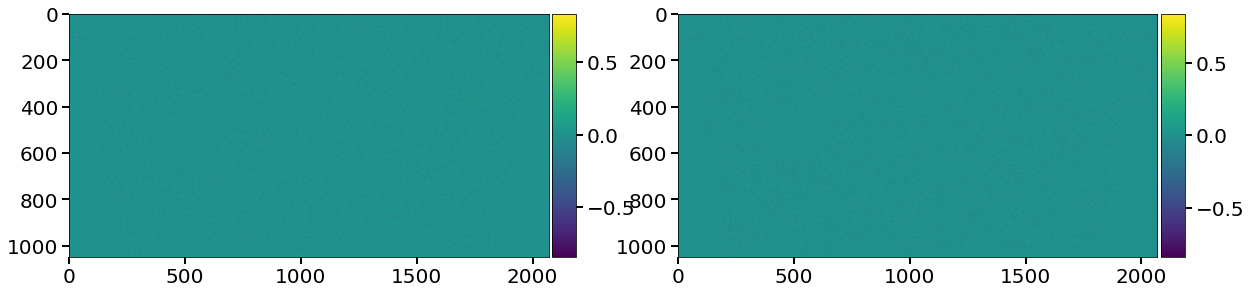

In [43]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
ax = plt.gca()
im = ax.imshow(g2map_uncal_10box)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right",size="5%",pad=0.05)
plt.colorbar(im,cax=cax)

plt.subplot(1,2,2)
ax = plt.gca()
im = ax.imshow(e2map_uncal)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right",size="5%",pad=0.05)
plt.colorbar(im,cax=cax)
plt.show()

In [44]:
# Quantity for correlation
psf1map, psf2map = bin2d(xx, yy, npix=(Nx,Ny), v=(Psf1,Psf2))
psf = np.array([psf1map,psf2map])

module_psf_map, size_gal_map, nepoch_map, mag_map, snr_map = bin2d(xx, yy, npix=(Nx,Ny), v=(module_psf,size_gal,nepoch,mag,snr_win))

In [45]:
def bin_Rshear(npix):
    # Binning of R shear on npix
    
    R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=npix, v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:])) 
    Rmap = np.array([[R_11,R_12],[R_21,R_22]])
    
    return Rmap

In [46]:
# R shear with binning on different px
Rmap1 = bin_Rshear(1)
Rmap5 = bin_Rshear(5)
Rmap10 = bin_Rshear(10)
Rmap32 = bin_Rshear(32)
Rmap64 = bin_Rshear(64)
Rmap128 = bin_Rshear(128)
Rmap256 = bin_Rshear(256)
Rmap512 = bin_Rshear(512)

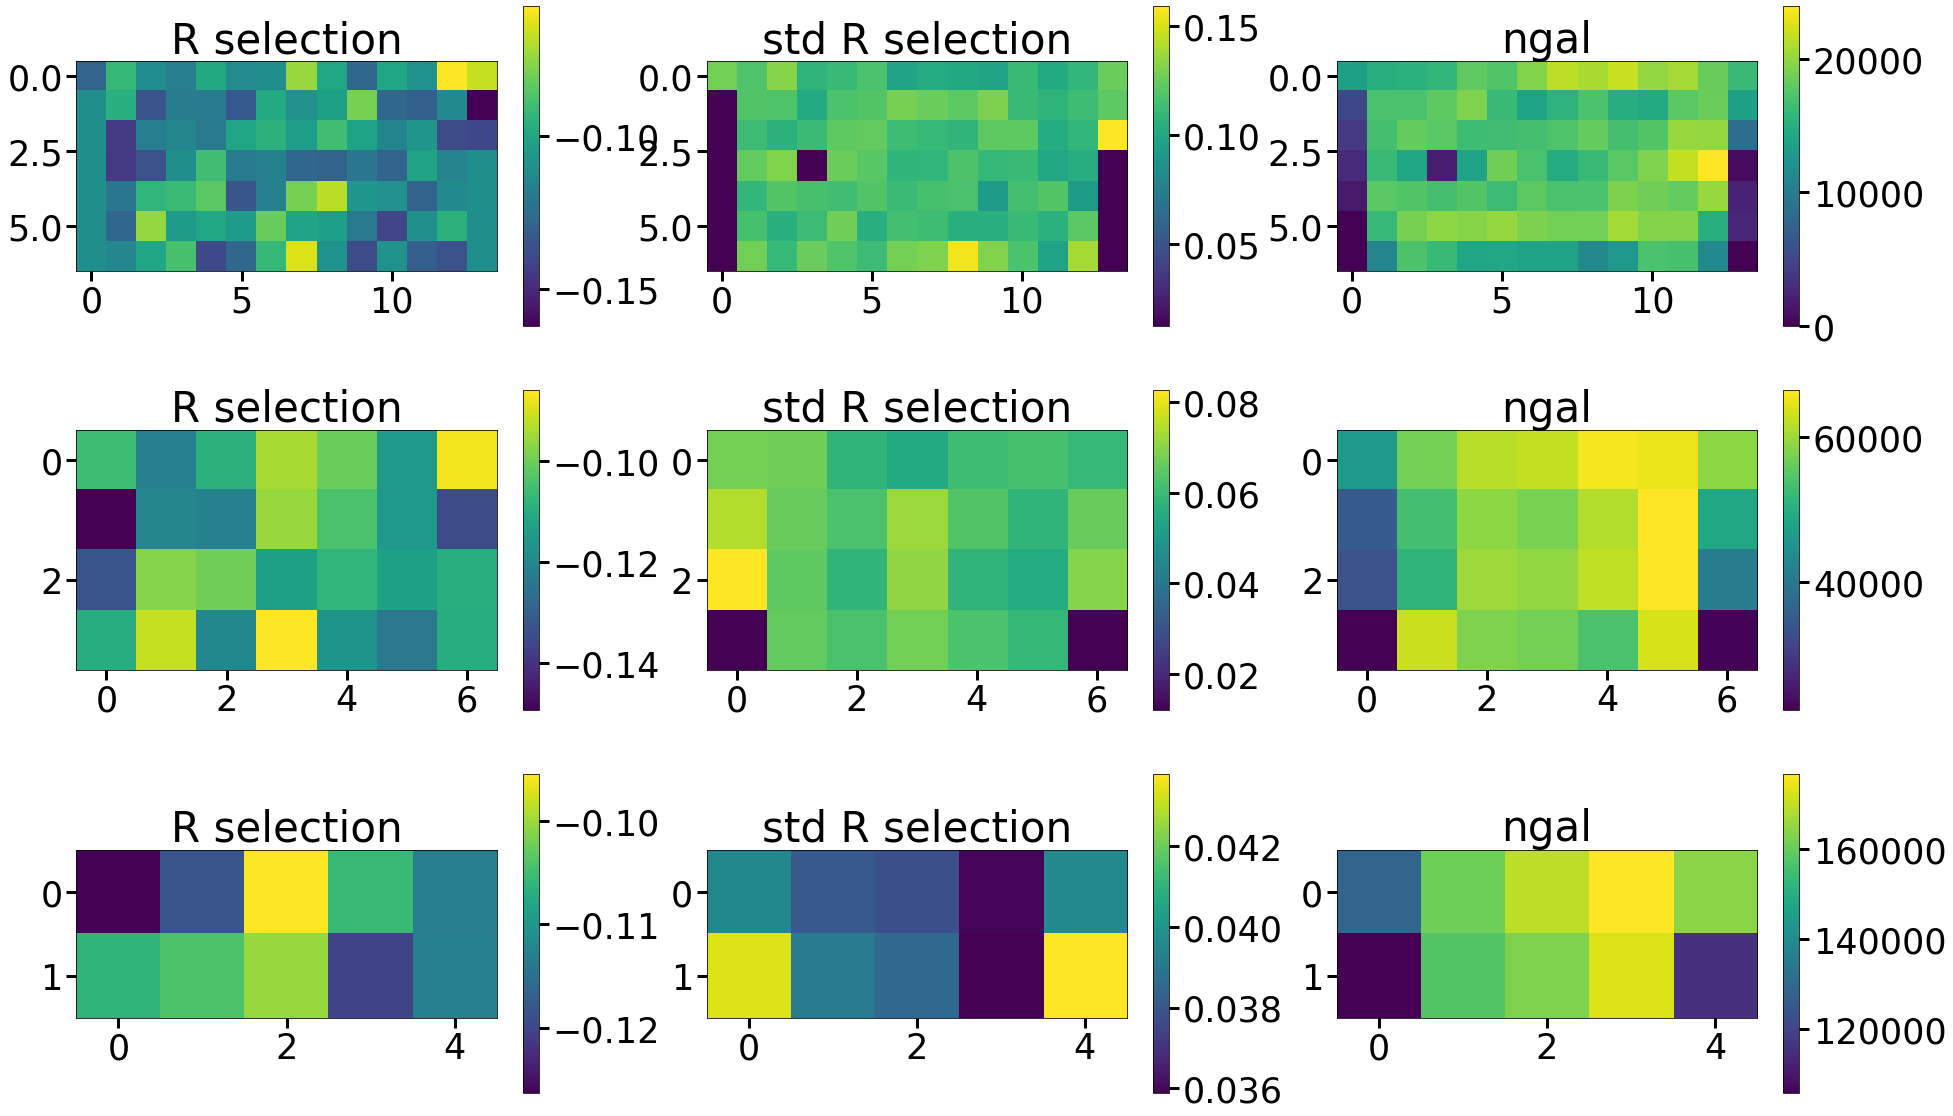

In [144]:
ngal = bin2d(xx, yy, npix=5)
ngaldeg = bin2d(xx,yy,npix=(14,7))
ngal2deg = bin2d(xx,yy,npix=(7,4))
ngal3deg = bin2d(xx,yy,npix=(5,2))

plt.figure(figsize=(32,20))
plt.subplot(3,3,1)
plt.imshow(R_selec_deg[0,0,:,:])
plt.colorbar()
plt.title('R selection')
plt.subplot(3,3,2)
plt.imshow(R_selec_std_deg[0,0,:,:])
plt.colorbar()
plt.title('std R selection')
plt.subplot(3,3,3)
plt.imshow(ngaldeg)
plt.title('ngal')
plt.colorbar()

plt.subplot(3,3,4)
plt.imshow(R_selec_2deg[0,0,:,:])
plt.colorbar()
plt.title('R selection')
plt.subplot(3,3,5)
plt.imshow(R_selec_std_2deg[0,0,:,:])
plt.colorbar()
plt.title('std R selection')
plt.subplot(3,3,6)
plt.imshow(ngal2deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(3,3,7)
plt.imshow(R_selec_3deg[0,0,:,:])
plt.colorbar()
plt.title('R selection')
plt.subplot(3,3,8)
plt.imshow(R_selec_std_3deg[0,0,:,:])
plt.colorbar()
plt.title('std R selection')
plt.subplot(3,3,9)
plt.imshow(ngal3deg)
plt.title('ngal')
plt.colorbar()
plt.savefig('./W3/R_selec.png')
plt.show()

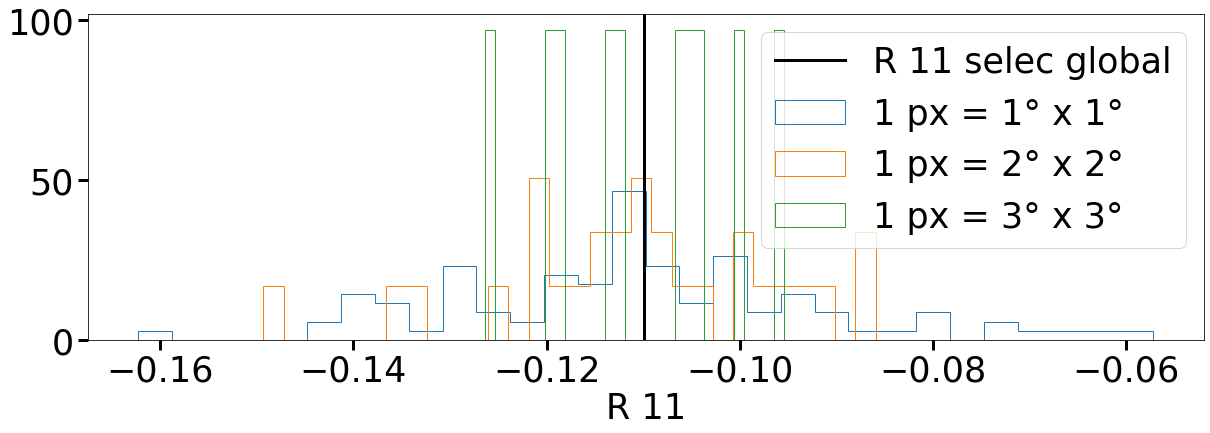

In [152]:
plt.figure(figsize=(20,6))
#plt.hist(np.ravel(R_selec_10box[0,0,:,:]),label='1 px = 1.38° x 0.7°',histtype='step',density=True,bins=30)
#plt.hist(np.ravel(R_selec_5box[0,0,:,:]),label='1 px = 2.76° x 1.4°',histtype='step',density=True,bins=30)
plt.hist(np.ravel(R_selec_deg[0,0,:,:]),label='1 px = 1° x 1°',histtype='step',density=True,bins=30)
plt.hist(np.ravel(R_selec_2deg[0,0,:,:]),label='1 px = 2° x 2°',histtype='step',density=True,bins=30)
plt.hist(np.ravel(R_selec_3deg[0,0,:,:]),label='1 px = 3° x 3°',histtype='step',density=True,bins=30)
plt.axvline(x=R_selec_moy[0,0],c='k',label='R 11 selec global')
plt.legend()
plt.xlabel('R 11')
plt.savefig('./W3/Rselec_hist.png')
plt.show()

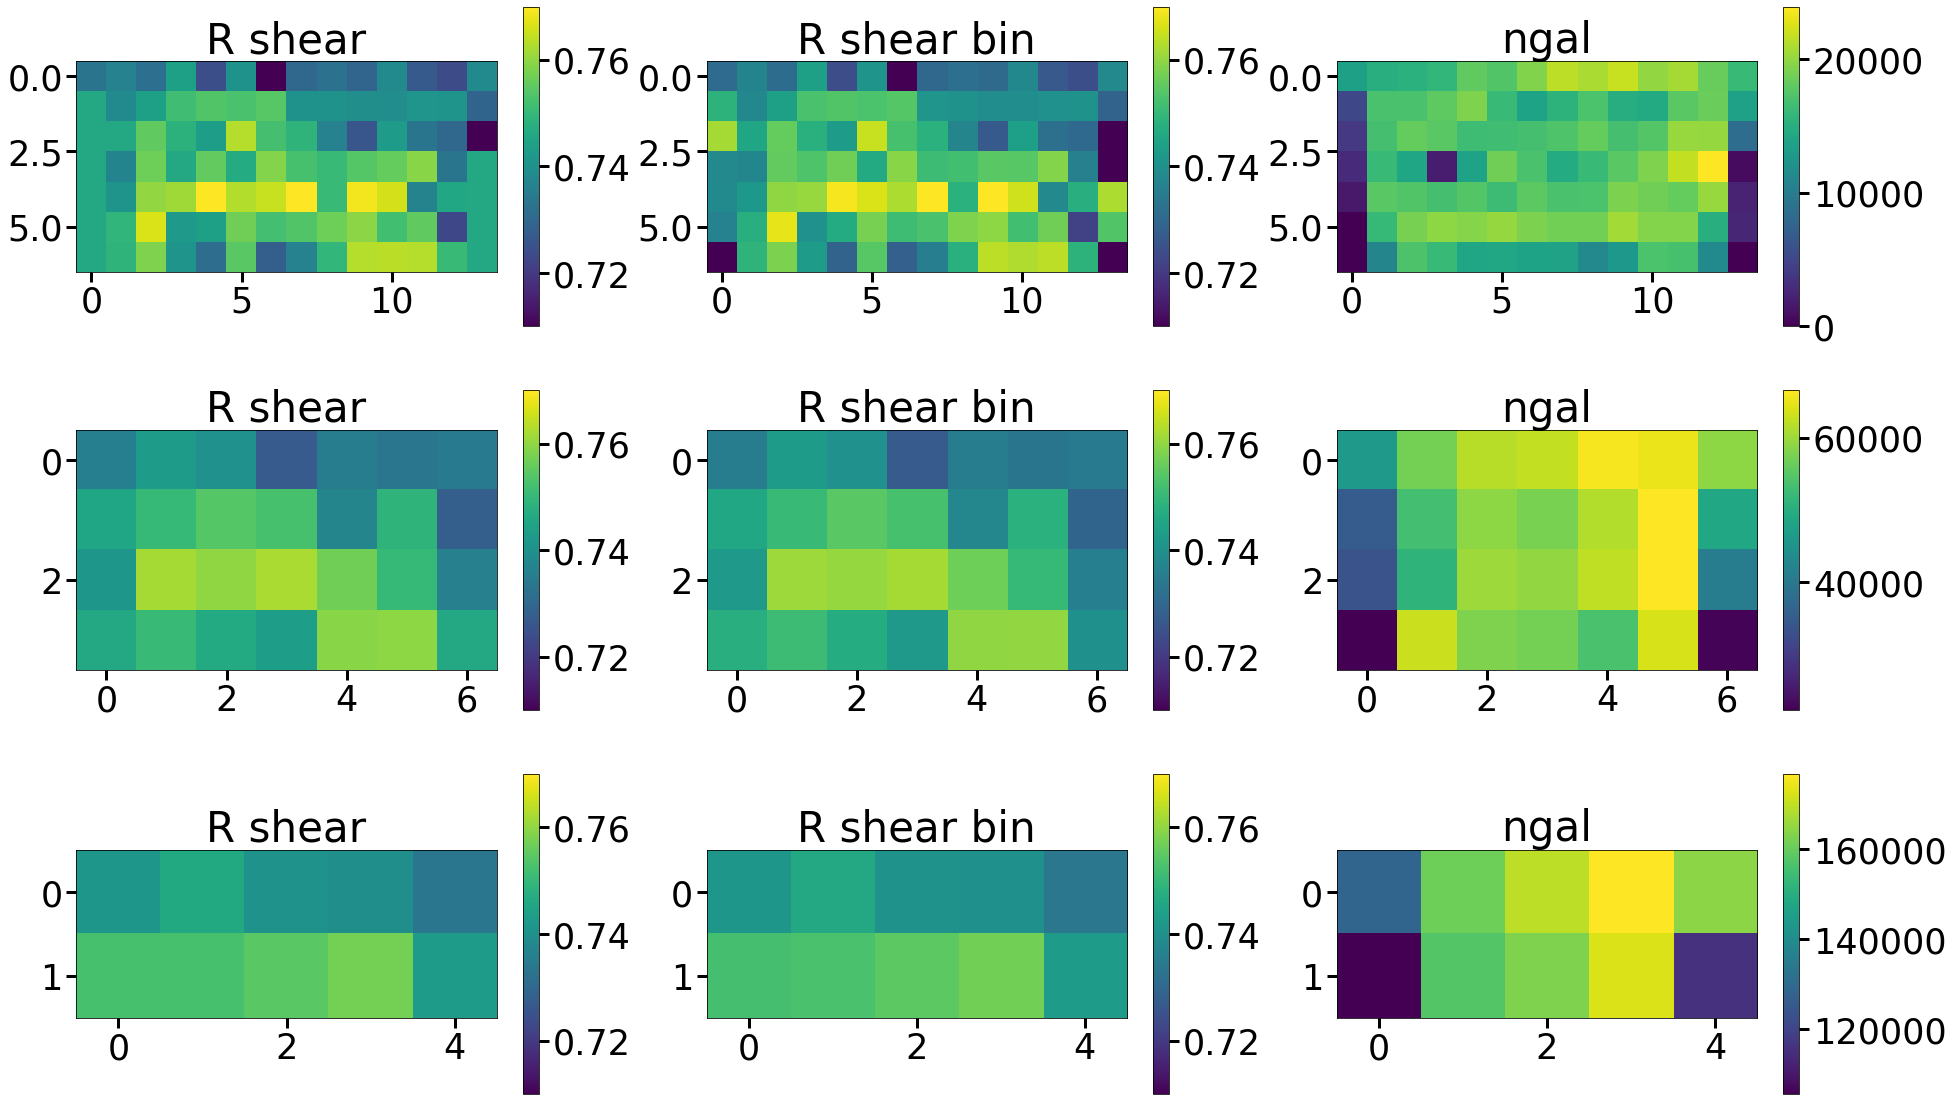

In [148]:
R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=(14,7), v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:])) 
Rmapdeg = np.array([[R_11,R_12],[R_21,R_22]])
R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=(7,4), v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:])) 
Rmap2deg = np.array([[R_11,R_12],[R_21,R_22]])
R_11, R_22, R_12, R_21 = bin2d(xx, yy, npix=(5,2), v=(gal_metacal_ngmix.R_shear[0,0,:],gal_metacal_ngmix.R_shear[1,1,:],gal_metacal_ngmix.R_shear[0,1,:],gal_metacal_ngmix.R_shear[1,0,:])) 
Rmap3deg = np.array([[R_11,R_12],[R_21,R_22]])
    
plt.figure(figsize=(32,20))
plt.subplot(3,3,1)
plt.imshow(R_shear_deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear')
plt.subplot(3,3,2)
plt.imshow(Rmapdeg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear bin')
plt.subplot(3,3,3)
plt.imshow(ngaldeg)
plt.title('ngal')
plt.colorbar()

plt.subplot(3,3,4)
plt.imshow(R_shear_2deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear')
plt.subplot(3,3,5)
plt.imshow(Rmap2deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear bin')
plt.subplot(3,3,6)
plt.imshow(ngal2deg)
plt.title('ngal')
plt.colorbar()

plt.subplot(3,3,7)
plt.imshow(R_shear_3deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear')
plt.subplot(3,3,8)
plt.imshow(Rmap3deg[0,0,:,:])
plt.colorbar()
plt.clim(0.71,0.77)
plt.title('R shear bin')
plt.subplot(3,3,9)
plt.imshow(ngal3deg)
plt.title('ngal')
plt.colorbar()
plt.savefig('./W3/R_shear.png')
plt.show()

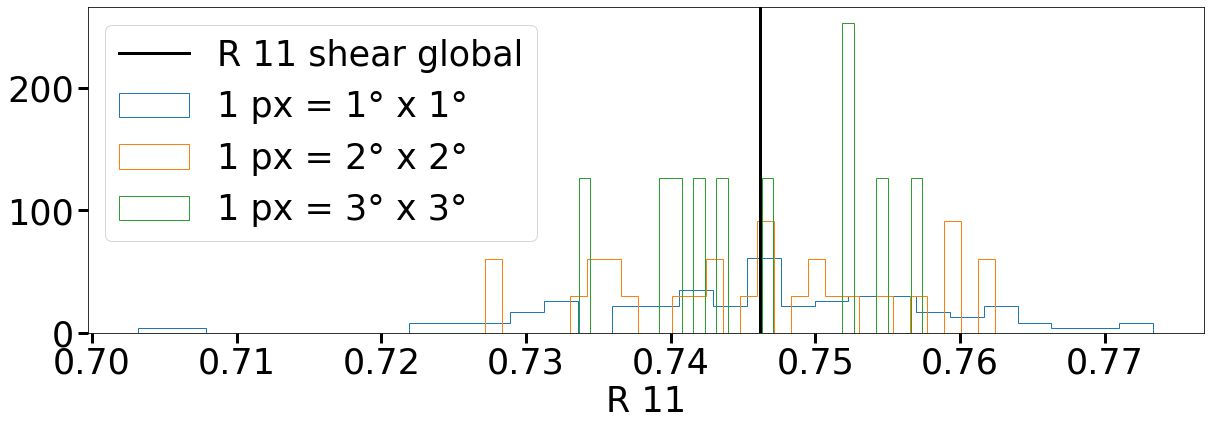

In [153]:
plt.figure(figsize=(20,6))
#plt.hist(np.ravel(R_shear_10box[0,0,:,:]),label='1 px = 1.38° x 0.7°',histtype='step',density=True,bins=30)
#plt.hist(np.ravel(R_shear_5box[0,0,:,:]),label='1 px = 2.76° x 1.4°',histtype='step',density=True,bins=30)
plt.hist(np.ravel(R_shear_deg[0,0,:,:]),label='1 px = 1° x 1°',histtype='step',density=True,bins=30)
plt.hist(np.ravel(R_shear_2deg[0,0,:,:]),label='1 px = 2° x 2°',histtype='step',density=True,bins=30)
plt.hist(np.ravel(R_shear_3deg[0,0,:,:]),label='1 px = 3° x 3°',histtype='step',density=True,bins=30)
plt.axvline(x=R_shear_moy[0,0],c='k',label='R 11 shear global')
plt.legend()
plt.xlabel('R 11')
plt.savefig('./W3/Rshear_hist.png')
plt.show()

In [53]:
ngal_10box = bin2d(xx, yy, npix=(10,10))

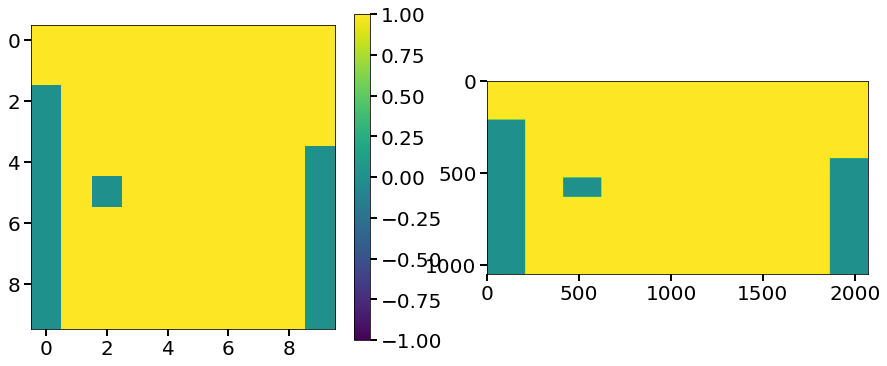

In [54]:
ngal_mask = np.ones((10,10))
for i in range(10):
    for j in range(10):
        if (ngal_10box[i,j] < 0.5*(np.mean(ngal_10box))):
            ngal_mask[i,j]=0
            
n_largex = 2070
n_largey = 1050
n_small = 10
ngal_mask_large = np.zeros((n_largey, n_largex))
srx = int(n_largex / n_small)
sry = int(n_largey/n_small)

for i in range(n_small):
    for j in range(n_small):
        r = np.ones((sry, srx)) * ngal_mask[i,j]
        ngal_mask_large[i*sry:(i+1)*sry, j*srx:(j+1)*srx] = r

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(ngal_mask)
plt.colorbar()
plt.clim(-1,1)
plt.subplot(1,2,2)
plt.imshow(ngal_mask_large)
plt.clim(-1,1)
plt.show()

In [55]:
def replace_Rshear(npix,R):
    # replace value were there is low number of galaxy per mean value
    
    ngal = bin2d(xx, yy, npix=npix)
    ind = np.where(ngal  < (np.mean(ngal))/2)
    Rmask = np.copy(R)
    Rmask[0,0,ind[0],ind[1]] = Rmap1[0,0,:,:]
    Rmask[0,1,ind[0],ind[1]] = Rmap1[0,1,:,:]
    Rmask[1,0,ind[0],ind[1]] = Rmap1[1,0,:,:]
    Rmask[1,1,ind[0],ind[1]] = Rmap1[1,1,:,:]
    
    return Rmask

In [56]:
ngaltot = bin2d(xx, yy, npix=(Nx,Ny))

In [57]:
# R shear with different binning, where value were there is low number of galaxy is replace by the mean value of Rshear
Rmask5 = replace_Rshear(5,Rmap5)
Rmask10 = replace_Rshear(10,Rmap10)
Rmask32 = replace_Rshear(32,Rmap32)
Rmask64 = replace_Rshear(64,Rmap64)
Rmask128 = replace_Rshear(128,Rmap128)
Rmask256 = replace_Rshear(256,Rmap256)
Rmask512 = replace_Rshear(512,Rmap512)

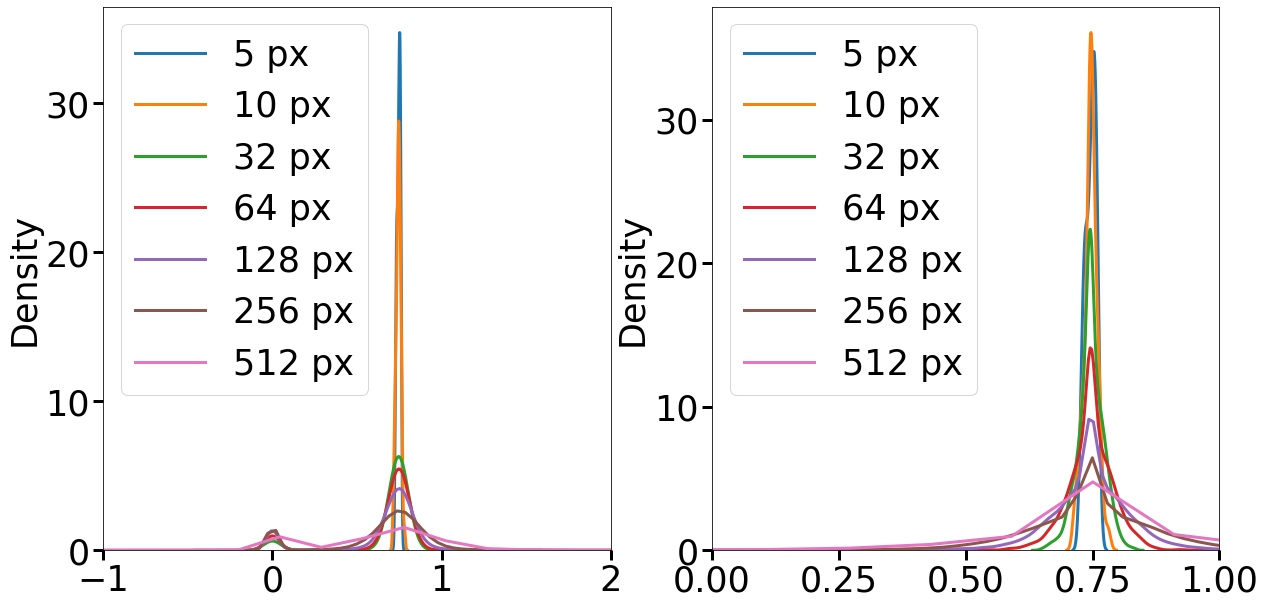

In [156]:
# Distribution of R11 before and after changing some values
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.kdeplot(np.ravel(Rmap5[0,0,:,:]),label='5 px')
sns.kdeplot(np.ravel(Rmap10[0,0,:,:]),label='10 px')
sns.kdeplot(np.ravel(Rmap32[0,0,:,:]),label='32 px')
sns.kdeplot(np.ravel(Rmap64[0,0,:,:]),label='64 px')
sns.kdeplot(np.ravel(Rmap128[0,0,:,:]),label='128 px')
sns.kdeplot(np.ravel(Rmap256[0,0,:,:]),label='256 px')
sns.kdeplot(np.ravel(Rmap512[0,0,:,:]),label='512 px')
plt.legend()
plt.xlim(-1,2)

plt.subplot(1,2,2)
sns.kdeplot(np.ravel(Rmask5[0,0,:,:]),label='5 px')
sns.kdeplot(np.ravel(Rmask10[0,0,:,:]),label='10 px')
sns.kdeplot(np.ravel(Rmask32[0,0,:,:]),label='32 px')
sns.kdeplot(np.ravel(Rmask64[0,0,:,:]),label='64 px')
sns.kdeplot(np.ravel(Rmask128[0,0,:,:]),label='128 px')
sns.kdeplot(np.ravel(Rmask256[0,0,:,:]),label='256 px')
sns.kdeplot(np.ravel(Rmask512[0,0,:,:]),label='512 px')
plt.legend()
plt.xlim(0,1)
plt.savefig('./W3/Rshear_hist_all.png')
plt.show()

In [62]:
def Rtot_extent(npix_y,npix_x,R):
    R_large = np.zeros((Ny, Nx))
    srx = int(Nx / npix_x)
    sry = int(Ny/npix_y)

    for i in range(npix_y):
        for j in range(npix_x):
            r = np.ones((sry, srx)) * R[i,j]
            R_large[i*sry:(i+1)*sry, j*srx:(j+1)*srx] = r
    return R_large

In [63]:
# Extend R shear from 10 box
Rshear_metacal_10box1 = Rtot_extent(10,10,R_shear_10box[0,0,:,:])
Rshear_metacal_10box2 = Rtot_extent(10,10,R_shear_10box[0,1,:,:])
Rshear_metacal_10box3 = Rtot_extent(10,10,R_shear_10box[1,0,:,:])
Rshear_metacal_10box4 = Rtot_extent(10,10,R_shear_10box[1,1,:,:])

Rshear_metacal_10box = np.zeros((2,2,Ny,Nx))
Rshear_metacal_10box[0,0,:,:] = Rshear_metacal_10box1
Rshear_metacal_10box[0,1,:,:] = Rshear_metacal_10box2
Rshear_metacal_10box[1,0,:,:] = Rshear_metacal_10box3
Rshear_metacal_10box[1,1,:,:] = Rshear_metacal_10box4

In [64]:
# Extend R shear from 5 box
Rshear_metacal_5box1 = Rtot_extent(5,5,R_shear_5box[0,0,:,:])
Rshear_metacal_5box2 = Rtot_extent(5,5,R_shear_5box[0,1,:,:])
Rshear_metacal_5box3 = Rtot_extent(5,5,R_shear_5box[1,0,:,:])
Rshear_metacal_5box4 = Rtot_extent(5,5,R_shear_5box[1,1,:,:])

Rshear_metacal_5box = np.zeros((2,2,Ny,Nx))
Rshear_metacal_5box[0,0,:,:] = Rshear_metacal_5box1
Rshear_metacal_5box[0,1,:,:] = Rshear_metacal_5box2
Rshear_metacal_5box[1,0,:,:] = Rshear_metacal_5box3
Rshear_metacal_5box[1,1,:,:] = Rshear_metacal_5box4

In [65]:
# Extend R shear from 5 box
Rshear_metacal_deg1 = Rtot_extent(7,14,R_shear_deg[0,0,:,:])
Rshear_metacal_deg2 = Rtot_extent(7,14,R_shear_deg[0,1,:,:])
Rshear_metacal_deg3 = Rtot_extent(7,14,R_shear_deg[1,0,:,:])
Rshear_metacal_deg4 = Rtot_extent(7,14,R_shear_deg[1,1,:,:])

Rshear_metacal_deg = np.zeros((2,2,Ny,Nx))
Rshear_metacal_deg[0,0,:,:] = Rshear_metacal_deg1
Rshear_metacal_deg[0,1,:,:] = Rshear_metacal_deg2
Rshear_metacal_deg[1,0,:,:] = Rshear_metacal_deg3
Rshear_metacal_deg[1,1,:,:] = Rshear_metacal_deg4

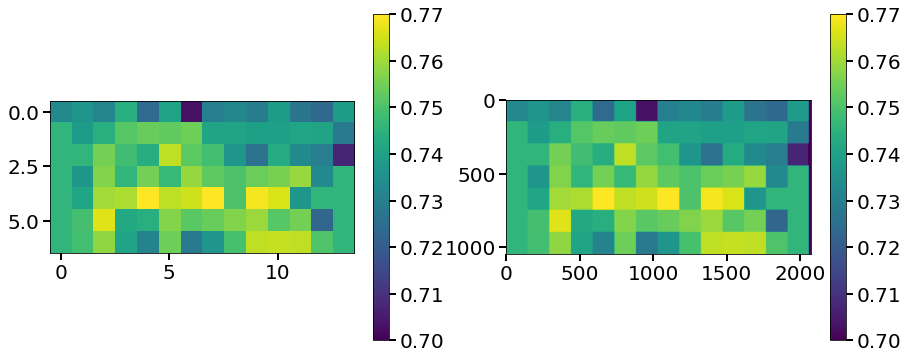

In [67]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(R_shear_deg[0,0,:,:])
plt.colorbar()
plt.clim(0.7,0.77)
plt.subplot(1,2,2)
plt.imshow(Rshear_metacal_deg[0,0,:,:])
plt.colorbar()
plt.clim(0.7,0.77)
plt.show()

In [68]:
# Extend R selec from 10 box
Rselec_metacal_10box1 = Rtot_extent(10,10,R_selec_10box[0,0,:,:])
Rselec_metacal_10box2 = Rtot_extent(10,10,R_selec_10box[0,1,:,:])
Rselec_metacal_10box3 = Rtot_extent(10,10,R_selec_10box[1,0,:,:])
Rselec_metacal_10box4 = Rtot_extent(10,10,R_selec_10box[1,1,:,:])

Rselec_metacal_10box = np.zeros((2,2,Ny,Nx))
Rselec_metacal_10box[0,0,:,:] = Rselec_metacal_10box1
Rselec_metacal_10box[0,1,:,:] = Rselec_metacal_10box2
Rselec_metacal_10box[1,0,:,:] = Rselec_metacal_10box3
Rselec_metacal_10box[1,1,:,:] = Rselec_metacal_10box4

# Extend R selec from 5 box
Rselec_metacal_5box1 = Rtot_extent(5,5,R_selec_5box[0,0,:,:])
Rselec_metacal_5box2 = Rtot_extent(5,5,R_selec_5box[0,1,:,:])
Rselec_metacal_5box3 = Rtot_extent(5,5,R_selec_5box[1,0,:,:])
Rselec_metacal_5box4 = Rtot_extent(5,5,R_selec_5box[1,1,:,:])

Rselec_metacal_5box = np.zeros((2,2,Ny,Nx))
Rselec_metacal_5box[0,0,:,:] = Rselec_metacal_5box1
Rselec_metacal_5box[0,1,:,:] = Rselec_metacal_5box2
Rselec_metacal_5box[1,0,:,:] = Rselec_metacal_5box3
Rselec_metacal_5box[1,1,:,:] = Rselec_metacal_5box4

In [93]:
def bin_Rtot(Rshear,Rselec):
    # R tot = R shear + R selection
    
    Rtot = np.zeros((2,2,Ny,Nx))
    for i in range(Ny):
        for j in range(Nx):
            Rtot[:,:,i,j] = Rshear[:,:,i,j] + Rselec[:,:,i,j]
    return Rtot

In [94]:
Rtot_metacal_10box = bin_Rtot(Rshear_metacal_10box,Rselec_metacal_10box)
Rtot_metacal_5box = bin_Rtot(Rshear_metacal_5box,Rselec_metacal_5box)

Kappa map

In [73]:
# Kappa map
kappaE_cal, kappaB_cal = ks93(e1map,-e2map) # Global calibration

kappaE_10box, kappaB_10box = ks93(gmap_10box[0], -gmap_10box[1]) # From metacal
kappaE_dm_10box, kappaB_dm_10box = ks93(gmap_dm_10box[0], -gmap_dm_10box[1])
kappaE_5box, kappaB_5box = ks93(gmap_5box[0], -gmap_5box[1]) 
kappaE_dm_5box, kappaB_dm_5box = ks93(gmap_dm_5box[0], -gmap_dm_5box[1])

kappaE_deg, kappaB_deg = ks93(gmap_deg[0], -gmap_deg[1]) # From metacal by deg
kappaE_2deg, kappaB_2deg = ks93(gmap_2deg[0], -gmap_2deg[1]) 
kappaE_3deg, kappaB_d3eg = ks93(gmap_3deg[0], -gmap_3deg[1])

kappaE_dm_deg, kappaB_dm_deg = ks93(gmap_dm_deg[0], -gmap_dm_deg[1]) # From metacal by deg with dm
kappaE_dm_2deg, kappaB_dm_2deg = ks93(gmap_dm_2deg[0], -gmap_dm_2deg[1]) 
kappaE_dm_3deg, kappaB_dm_d3eg = ks93(gmap_dm_3deg[0], -gmap_dm_3deg[1])

In [74]:
#hdu = fits.PrimaryHDU(kappaE_dm_5box)
#hdul = fits.HDUList([hdu])
#hdul.writeto('./W3/kappaE_dm_5box.fits')

In [75]:
#galaxy number density in gal/arcmin^2
n_gal=7 # gal/arcmin^2 in the survey

#pixel size in arcmin
pix_arcmin=0.4

#compute shape noise for CFIS
shape_noise=0.44
sigma_noise_CFIS=shape_noise/(np.sqrt(2*n_gal*pix_arcmin**2))
noise_CFIS_z05=sigma_noise_CFIS*np.random.randn(Ny, Nx)

In [76]:
#smooth the map with Gaussian kernel
precision_Peaks = 2/pix_arcmin

kappa_noisy_smoothedB = ndi.gaussian_filter(kappaB_cal, precision_Peaks) # Global
kappa_noisy_smoothed_cal = ndi.gaussian_filter(kappaE_cal, precision_Peaks)

kappa_noisy_smoothed_10box = ndi.gaussian_filter(kappaE_10box, precision_Peaks)
kappa_noisy_smoothed_dm_10box = ndi.gaussian_filter(kappaE_dm_10box, precision_Peaks)
kappa_noisy_smoothed_5box = ndi.gaussian_filter(kappaE_5box, precision_Peaks)
kappa_noisy_smoothed_dm_5box = ndi.gaussian_filter(kappaE_dm_5box, precision_Peaks)

kappa_noisy_smoothed_deg = ndi.gaussian_filter(kappaE_deg, precision_Peaks)
kappa_noisy_smoothed_2deg = ndi.gaussian_filter(kappaE_2deg, precision_Peaks)
kappa_noisy_smoothed_3deg = ndi.gaussian_filter(kappaE_3deg, precision_Peaks)

kappa_noisy_smoothed_dm_deg = ndi.gaussian_filter(kappaE_dm_deg, precision_Peaks)
kappa_noisy_smoothed_dm_2deg = ndi.gaussian_filter(kappaE_dm_2deg, precision_Peaks)
kappa_noisy_smoothed_dm_3deg = ndi.gaussian_filter(kappaE_dm_3deg, precision_Peaks)

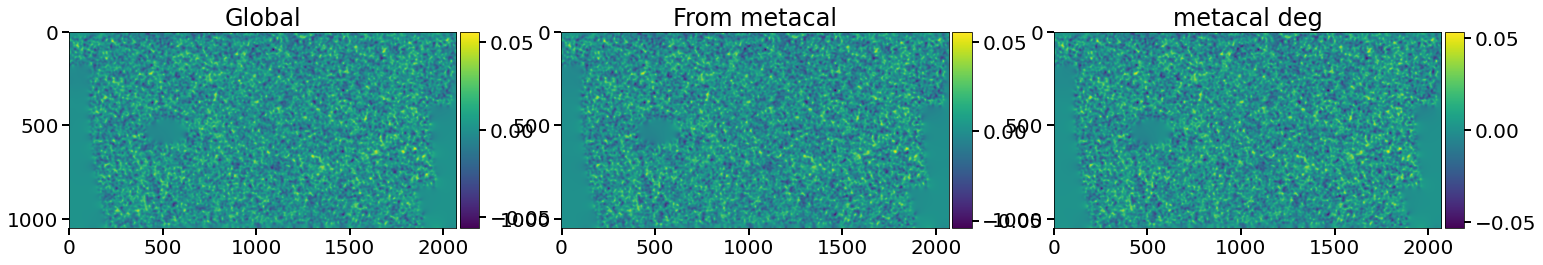

In [77]:
plt.figure(figsize=(25,10))
plt.subplot(1,3,1)
ax = plt.gca()
im = ax.imshow(kappa_noisy_smoothed_cal)
divider = make_axes_locatable(ax)
plt.title('Global')
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)

plt.subplot(1,3,2)
ax = plt.gca()
im = ax.imshow(kappa_noisy_smoothed_10box)
divider = make_axes_locatable(ax)
plt.title('From metacal')
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)

plt.subplot(1,3,3)
ax = plt.gca()
im = ax.imshow(kappa_noisy_smoothed_deg)
divider = make_axes_locatable(ax)
plt.title('metacal deg')
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)
plt.show()

In [78]:
# snr map
snr_cal = kappa_noisy_smoothed_cal/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snrB = kappa_noisy_smoothedB/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))

snr_10box = kappa_noisy_smoothed_10box/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_dm_10box = kappa_noisy_smoothed_dm_10box/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_5box = kappa_noisy_smoothed_5box/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_dm_5box = kappa_noisy_smoothed_dm_5box/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))

snr_deg = kappa_noisy_smoothed_deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_2deg = kappa_noisy_smoothed_2deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_3deg = kappa_noisy_smoothed_3deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))

snr_dm_deg = kappa_noisy_smoothed_dm_deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_dm_2deg = kappa_noisy_smoothed_dm_2deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))
snr_dm_3deg = kappa_noisy_smoothed_dm_3deg/np.std(ndi.gaussian_filter(noise_CFIS_z05, precision_Peaks))

In [79]:
# Compute peak count on kappa smooth
kappa_th = np.linspace(-0.06, 0.06, 31)
kappa_th_center = 0.5*(kappa_th[:-1]+kappa_th[1:])

peak_counts_cal, bins_cal = peaks.peaks_histogram(kappa_noisy_smoothed_cal,kappa_th)

peak_counts_10box, bins = peaks.peaks_histogram(kappa_noisy_smoothed_10box,kappa_th)
peak_counts_dm_10box, bins = peaks.peaks_histogram(kappa_noisy_smoothed_dm_10box,kappa_th)
peak_counts_5box, bins = peaks.peaks_histogram(kappa_noisy_smoothed_5box,kappa_th)
peak_counts_dm_5box, bins = peaks.peaks_histogram(kappa_noisy_smoothed_dm_5box,kappa_th)

peak_counts_deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_deg,kappa_th)
peak_counts_2deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_2deg,kappa_th)
peak_counts_3deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_3deg,kappa_th)

peak_counts_dm_deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_dm_deg,kappa_th)
peak_counts_dm_2deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_dm_2deg,kappa_th)
peak_counts_dm_3deg, bins = peaks.peaks_histogram(kappa_noisy_smoothed_dm_3deg,kappa_th)

In [81]:
# Compute peaks on snr map
kappa_snr = np.linspace(-2,6,31)
kappa_th_center_snr = 0.5*(kappa_snr[:-1]+kappa_snr[1:])

peak_counts_cal_snr, bins_cal = peaks.peaks_histogram(snr_cal,kappa_snr)

peak_counts_10box_snr, bins = peaks.peaks_histogram(snr_10box,kappa_snr)
peak_counts_dm_10box_snr, bins = peaks.peaks_histogram(snr_dm_10box,kappa_snr)
peak_counts_5box_snr, bins = peaks.peaks_histogram(snr_5box,kappa_snr)
peak_counts_dm_5box_snr, bins = peaks.peaks_histogram(snr_dm_5box,kappa_snr)

peak_counts_deg_snr, bins = peaks.peaks_histogram(snr_deg,kappa_snr)
peak_counts_2deg_snr, bins = peaks.peaks_histogram(snr_2deg,kappa_snr)
peak_counts_3deg_snr, bins = peaks.peaks_histogram(snr_3deg,kappa_snr)

peak_counts_dm_deg_snr, bins = peaks.peaks_histogram(snr_dm_deg,kappa_snr)
peak_counts_dm_2deg_snr, bins = peaks.peaks_histogram(snr_dm_2deg,kappa_snr)
peak_counts_dm_3deg_snr, bins = peaks.peaks_histogram(snr_dm_3deg,kappa_snr)

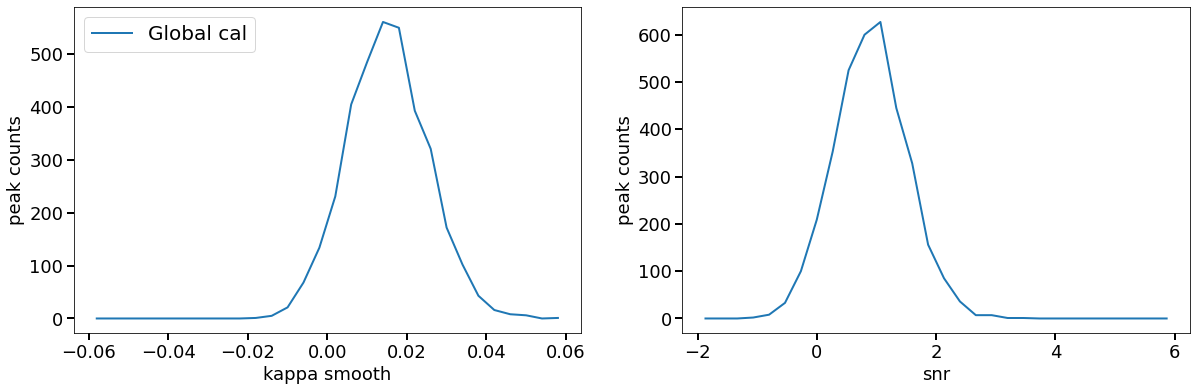

In [82]:
#plot single-Gaussian peak counts : Verification
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(kappa_th_center,peak_counts_cal,label='Global cal')
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('kappa smooth', fontsize=18)
plt.ylabel('peak counts', fontsize=18)
plt.subplot(1,2,2)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)
plt.show()

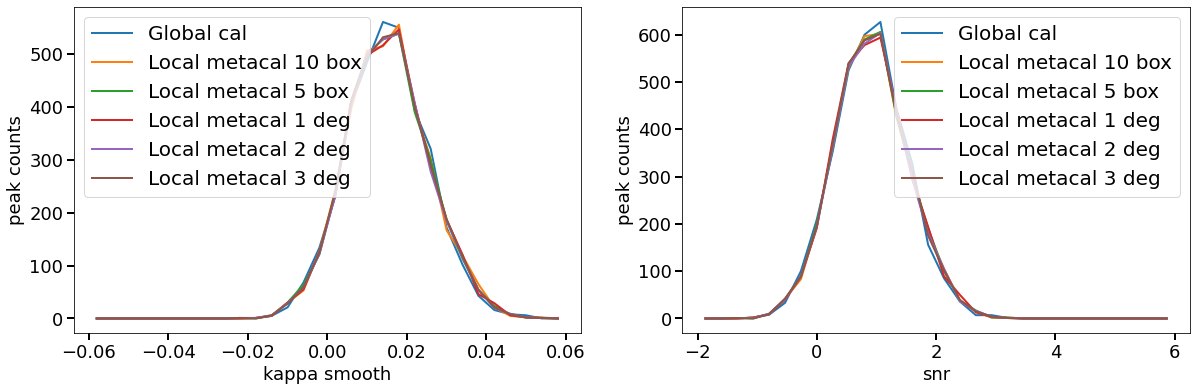

In [83]:
#plot single-Gaussian peak counts : method
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(kappa_th_center,peak_counts_cal,label='Global cal')
plt.plot(kappa_th_center,peak_counts_10box,label='Local metacal 10 box')
plt.plot(kappa_th_center,peak_counts_5box,label='Local metacal 5 box')
plt.plot(kappa_th_center,peak_counts_deg,label='Local metacal 1 deg')
plt.plot(kappa_th_center,peak_counts_2deg,label='Local metacal 2 deg')
plt.plot(kappa_th_center,peak_counts_3deg,label='Local metacal 3 deg')
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('kappa smooth', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(1,2,2)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_10box_snr,label='Local metacal 10 box')
plt.plot(kappa_th_center_snr,peak_counts_5box_snr,label='Local metacal 5 box')
plt.plot(kappa_th_center_snr,peak_counts_deg_snr,label='Local metacal 1 deg')
plt.plot(kappa_th_center_snr,peak_counts_2deg_snr,label='Local metacal 2 deg')
plt.plot(kappa_th_center_snr,peak_counts_3deg_snr,label='Local metacal 3 deg')
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)
plt.show()

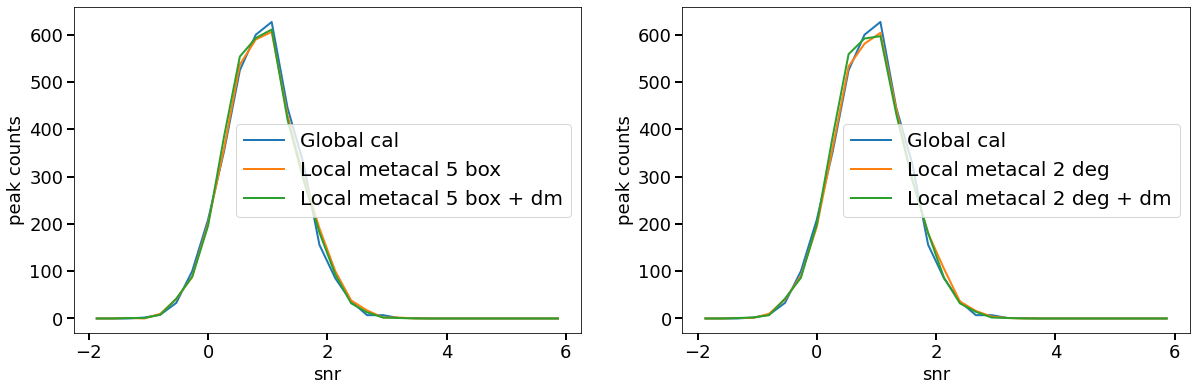

In [84]:
#plot single-Gaussian peak counts : method
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_5box_snr,label='Local metacal 5 box')
plt.plot(kappa_th_center_snr,peak_counts_dm_5box_snr,label='Local metacal 5 box + dm')
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(1,2,2)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_2deg_snr,label='Local metacal 2 deg')
plt.plot(kappa_th_center_snr,peak_counts_dm_2deg_snr,label='Local metacal 2 deg + dm')
plt.legend()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)
plt.savefig('./W3/snr_peaks_method.jpg')
plt.show()

/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: divide by zero encountered in true_divide
  if sys.path[0] == '':
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in true_divide
  if sys.path[0] == '':
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in true_divide
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: divide by zero encountered in true_divide
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountered in true_divide


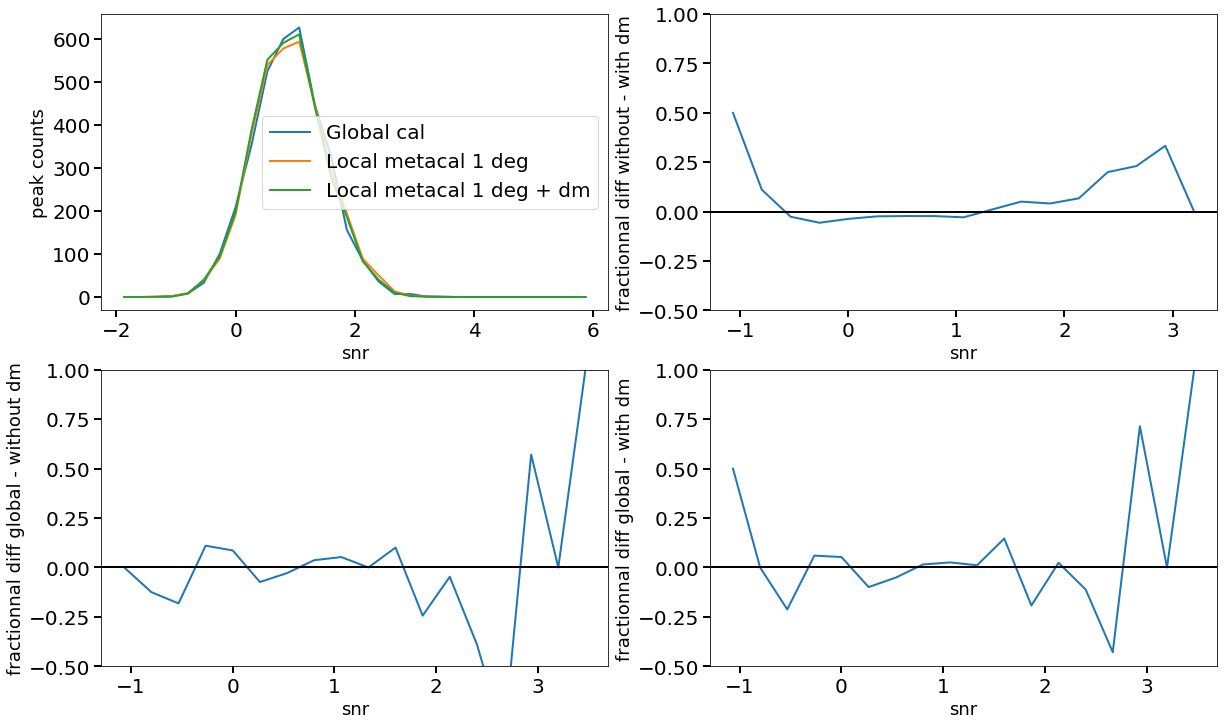

In [85]:
#plot single-Gaussian peak counts from metacal on patches
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_deg_snr,label='Local metacal 1 deg')
plt.plot(kappa_th_center_snr,peak_counts_dm_deg_snr,label='Local metacal 1 deg + dm')
plt.legend()
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(2,2,2)
plt.plot(kappa_th_center_snr,(peak_counts_deg_snr-peak_counts_dm_deg_snr)/peak_counts_deg_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff without - with dm', fontsize=18)

plt.subplot(2,2,3)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - without dm', fontsize=18)

plt.subplot(2,2,4)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_dm_deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - with dm', fontsize=18)
plt.savefig('./W3/frac_diff_1deg.jpg')
plt.show()

/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in true_divide
  if sys.path[0] == '':
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: divide by zero encountered in true_divide
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in true_divide
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: divide by zero encountered in true_divide
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountered in true_divide


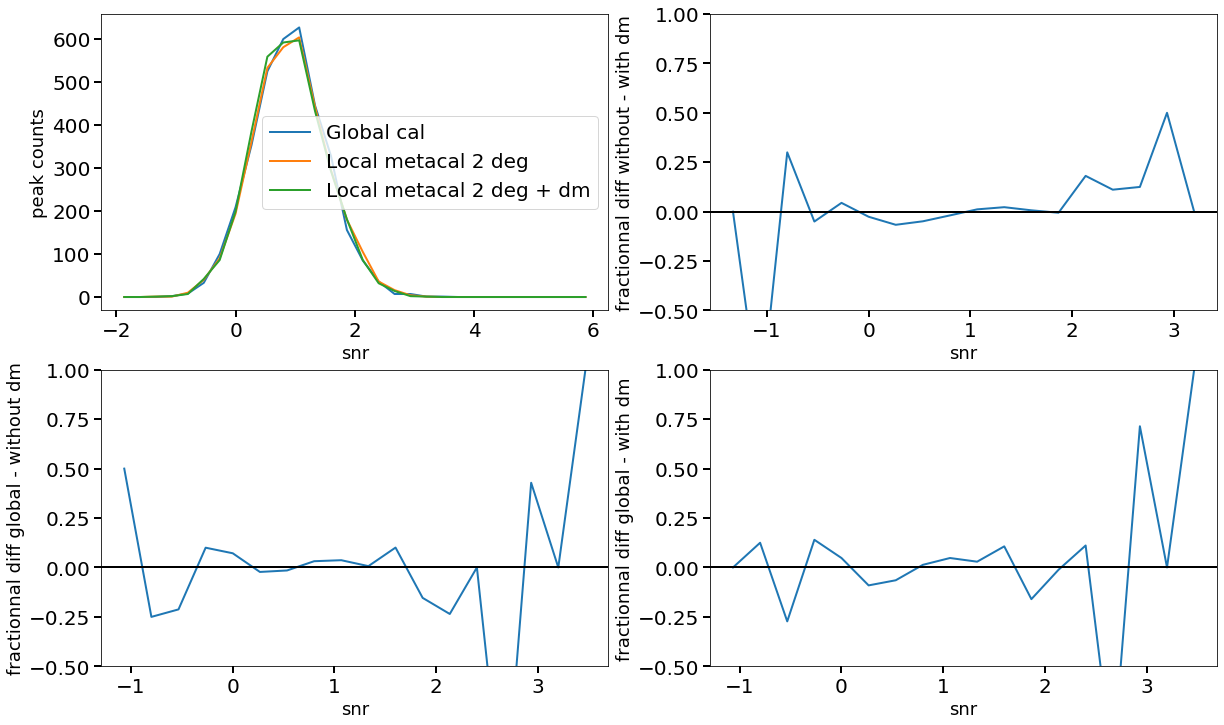

In [86]:
#plot single-Gaussian peak counts from metacal on patches
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_2deg_snr,label='Local metacal 2 deg')
plt.plot(kappa_th_center_snr,peak_counts_dm_2deg_snr,label='Local metacal 2 deg + dm')
plt.legend()
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(2,2,2)
plt.plot(kappa_th_center_snr,(peak_counts_2deg_snr-peak_counts_dm_2deg_snr)/peak_counts_2deg_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff without - with dm', fontsize=18)

plt.subplot(2,2,3)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_2deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - without dm', fontsize=18)

plt.subplot(2,2,4)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_dm_2deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - with dm', fontsize=18)
plt.savefig('./W3/frac_diff_2deg.jpg')
plt.show()

/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: divide by zero encountered in true_divide
  if sys.path[0] == '':
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in true_divide
  if sys.path[0] == '':
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: divide by zero encountered in true_divide
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in true_divide
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: divide by zero encountered in true_divide
/Users/emmaaycoberry/opt/anaconda3/envs/shapepipe/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountere

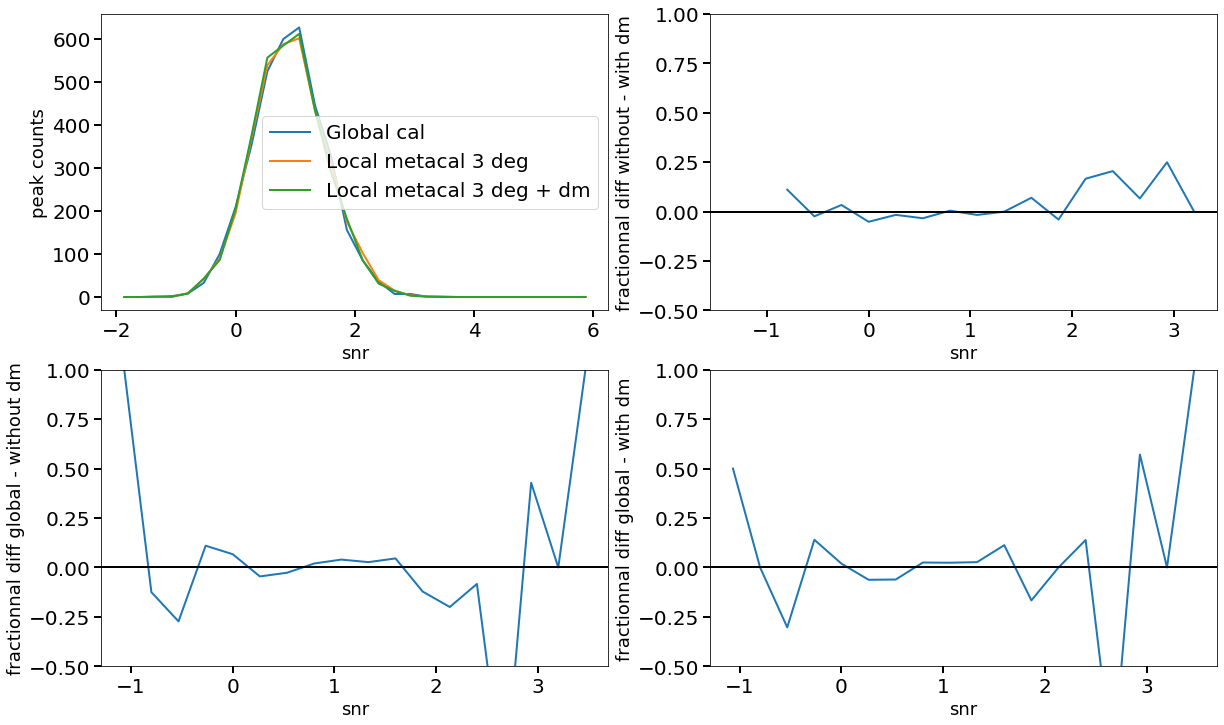

In [87]:

#plot single-Gaussian peak counts from metacal on patches
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
plt.plot(kappa_th_center_snr,peak_counts_cal_snr,label='Global cal')
plt.plot(kappa_th_center_snr,peak_counts_3deg_snr,label='Local metacal 3 deg')
plt.plot(kappa_th_center_snr,peak_counts_dm_3deg_snr,label='Local metacal 3 deg + dm')
plt.legend()
plt.xlabel('snr', fontsize=18)
plt.ylabel('peak counts', fontsize=18)

plt.subplot(2,2,2)
plt.plot(kappa_th_center_snr,(peak_counts_3deg_snr-peak_counts_dm_3deg_snr)/peak_counts_3deg_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff without - with dm', fontsize=18)

plt.subplot(2,2,3)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_3deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - without dm', fontsize=18)

plt.subplot(2,2,4)
plt.plot(kappa_th_center_snr,(peak_counts_cal_snr-peak_counts_dm_3deg_snr)/peak_counts_cal_snr)
plt.axhline(y=0,c='k')
plt.ylim(-0.5,1)
plt.xlabel('snr', fontsize=18)
plt.ylabel('fractionnal diff global - with dm', fontsize=18)
plt.savefig('./W3/frac_diff_3deg.jpg')
plt.show()

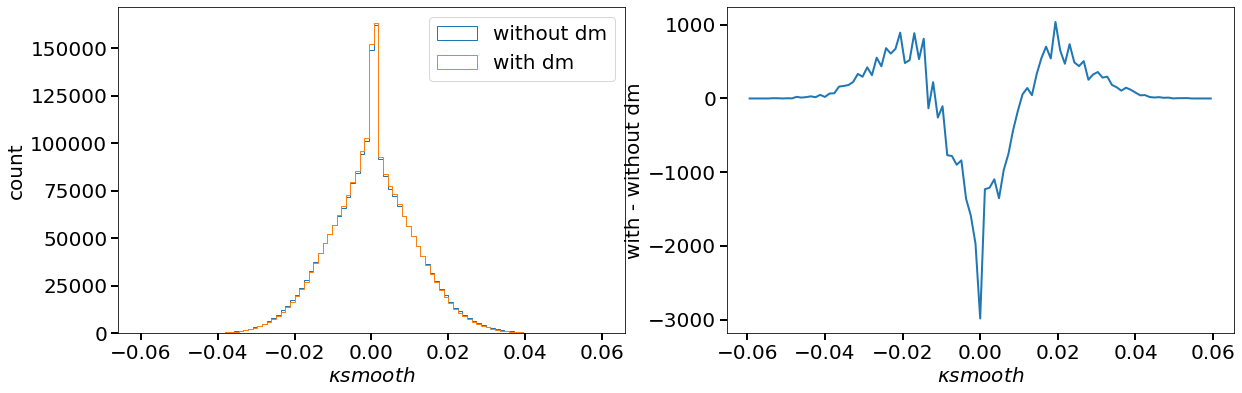

In [88]:
# Histogram to see difference btw R^-1 * e with and without dm
kappa_map1D_deg= np.ravel(kappa_noisy_smoothed_deg)
kappa_map1D_dm_deg = np.ravel(kappa_noisy_smoothed_dm_deg)

kappa_th_hist = np.linspace(-0.06, 0.06, 100)
kappa_th_center_hist = 0.5*(kappa_th_hist[:-1]+kappa_th_hist[1:])

kappa_map_1D_hist_deg, bins1 = np.histogram(kappa_map1D_deg,bins=kappa_th_hist)
kappa_map_1D_dm_hist_deg, bins2 = np.histogram(kappa_map1D_dm_deg,bins=kappa_th_hist)

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.hist(kappa_map1D_deg,label='without dm',histtype='step',bins=kappa_th_hist)
plt.hist(kappa_map1D_dm_deg,label='with dm',histtype='step',bins=kappa_th_hist)
plt.xlabel('$\kappa smooth$')
plt.ylabel('count')
plt.legend()
plt.subplot(1,2,2)
plt.plot(kappa_th_center_hist,(kappa_map_1D_hist_deg-kappa_map_1D_dm_hist_deg))
plt.xlabel('$\kappa smooth$')
plt.ylabel('with - without dm')
plt.savefig('./W3/hist_diff_1deg.jpg')
plt.show()

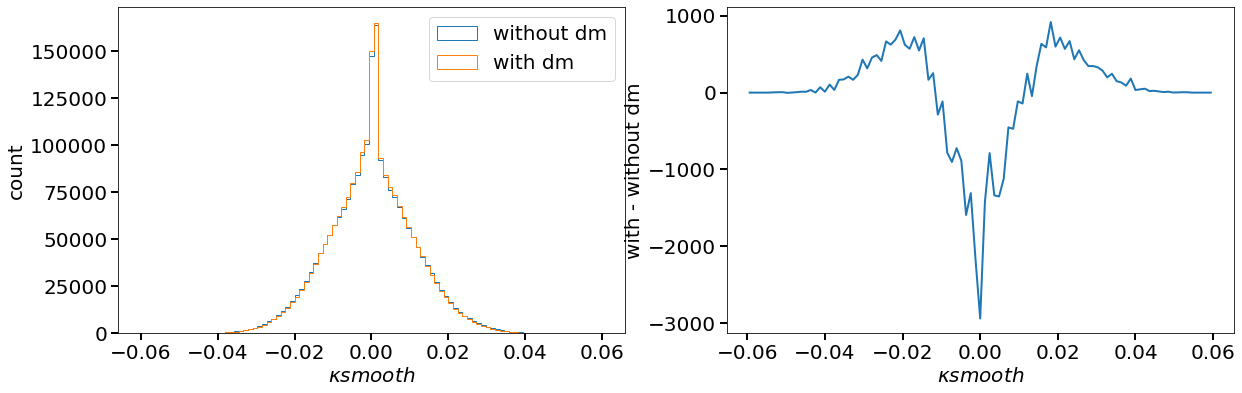

In [89]:
# Histogram to see difference btw R^-1 * e with and without dm
kappa_map1D_2deg= np.ravel(kappa_noisy_smoothed_2deg)
kappa_map1D_dm_2deg = np.ravel(kappa_noisy_smoothed_dm_2deg)

kappa_map_1D_hist_2deg, bins1 = np.histogram(kappa_map1D_2deg,bins=kappa_th_hist)
kappa_map_1D_dm_hist_2deg, bins2 = np.histogram(kappa_map1D_dm_2deg,bins=kappa_th_hist)

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.hist(kappa_map1D_2deg,label='without dm',histtype='step',bins=kappa_th_hist)
plt.hist(kappa_map1D_dm_2deg,label='with dm',histtype='step',bins=kappa_th_hist)
plt.xlabel('$\kappa smooth$')
plt.ylabel('count')
plt.legend()
plt.subplot(1,2,2)
plt.plot(kappa_th_center_hist,(kappa_map_1D_hist_2deg-kappa_map_1D_dm_hist_2deg))
plt.xlabel('$\kappa smooth$')
plt.ylabel('with - without dm')
plt.savefig('./W3/hist_diff_2deg.jpg')
plt.show()

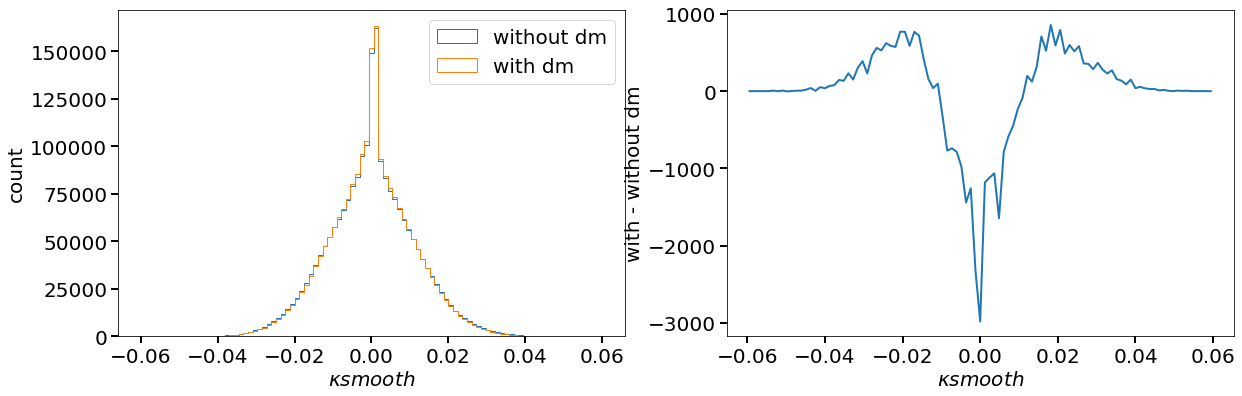

In [90]:
# Histogram to see difference btw R^-1 * e with and without dm
kappa_map1D_3deg= np.ravel(kappa_noisy_smoothed_3deg)
kappa_map1D_dm_3deg = np.ravel(kappa_noisy_smoothed_dm_3deg)

kappa_map_1D_hist_3deg, bins1 = np.histogram(kappa_map1D_3deg,bins=kappa_th_hist)
kappa_map_1D_dm_hist_3deg, bins2 = np.histogram(kappa_map1D_dm_3deg,bins=kappa_th_hist)

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.hist(kappa_map1D_3deg,label='without dm',histtype='step',bins=kappa_th_hist)
plt.hist(kappa_map1D_dm_3deg,label='with dm',histtype='step',bins=kappa_th_hist)
plt.xlabel('$\kappa smooth$')
plt.ylabel('count')
plt.legend()
plt.subplot(1,2,2)
plt.plot(kappa_th_center_hist,(kappa_map_1D_hist_3deg-kappa_map_1D_dm_hist_3deg))
plt.xlabel('$\kappa smooth$')
plt.ylabel('with - without dm')
plt.savefig('./W3/hist_diff_3deg.jpg')
plt.show()

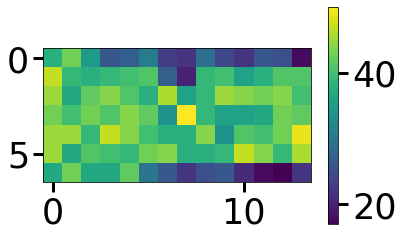

In [126]:
# Find the peaks positions and bin it
x_peaks, y_peaks, h_peaks = find_peaks2d(snr_cal, threshold=-2, include_border=True)
pos_peaks = bin2d(x_peaks, y_peaks, npix=(14,7))

x_peaks2, y_peaks2, h_peaks = find_peaks2d(snr_cal, threshold=-2, include_border=True)
pos_peaks2 = bin2d(x_peaks, y_peaks, npix=(7,4))

x_peaks3, y_peaks3, h_peaks = find_peaks2d(snr_cal, threshold=-2, include_border=True)
pos_peaks3 = bin2d(x_peaks, y_peaks, npix=(5,2))

plt.figure()
plt.imshow(pos_peaks)
plt.colorbar()
plt.show()

Cross correlation

In [91]:
from scipy import stats
stats.pearsonr(np.ravel(kappaE_cal),np.ravel(kappaB_cal))

(0.0009441245481553661, 0.1639517845502881)

In [131]:
data = {'n gal': np.ravel(ngaltot),
        'kappa_E': np.ravel(kappaE_cal),
        'kappa_E smooth': np.ravel(kappa_noisy_smoothed_cal),
        'kappa_B': np.ravel(kappaB_cal),
        'kappa_B smooth': np.ravel(kappa_noisy_smoothedB),
        'kappa_E 10 box': np.ravel(kappaE_10box),
        'kappa_B 10 box': np.ravel(kappaB_10box),
        'kappa_E 5 box': np.ravel(kappaE_5box),
        'kappa_B 5 box': np.ravel(kappaB_5box),
        'R_11 shear': np.ravel(Rshear_metacal_10box[0,0,:,:]),
        'R_22 shear': np.ravel(Rshear_metacal_10box[1,1,:,:]),
        'R_12 shear': np.ravel(Rshear_metacal_10box[0,1,:,:]),
        'R_21 shear': np.ravel(Rshear_metacal_10box[1,0,:,:]),
        'R_11 selec': np.ravel(Rselec_metacal_10box[0,0,:,:]),
        'R_22 selec': np.ravel(Rselec_metacal_10box[1,1,:,:]),
        'R_12 selec': np.ravel(Rselec_metacal_10box[0,1,:,:]),
        'R_21 selec': np.ravel(Rselec_metacal_10box[1,0,:,:]),
        'R_11 tot': np.ravel(Rtot_metacal_10box[0,0,:,:]),
        'R_22 tot': np.ravel(Rtot_metacal_10box[1,1,:,:]),
        'R_12 tot': np.ravel(Rtot_metacal_10box[0,1,:,:]),
        'R_21 tot': np.ravel(Rtot_metacal_10box[1,0,:,:]),
        'R_11 shear 5': np.ravel(Rshear_metacal_5box[0,0,:,:]),
        'R_22 shear 5': np.ravel(Rshear_metacal_5box[1,1,:,:]),
        'R_12 shear 5': np.ravel(Rshear_metacal_5box[0,1,:,:]),
        'R_21 shear 5': np.ravel(Rshear_metacal_5box[1,0,:,:]),
        'R_11 selec 5': np.ravel(Rselec_metacal_5box[0,0,:,:]),
        'R_22 selec 5': np.ravel(Rselec_metacal_5box[1,1,:,:]),
        'R_12 selec 5': np.ravel(Rselec_metacal_5box[0,1,:,:]),
        'R_21 selec 5': np.ravel(Rselec_metacal_5box[1,0,:,:]),
        'R_11 tot 5': np.ravel(Rtot_metacal_5box[0,0,:,:]),
        'R_22 tot 5': np.ravel(Rtot_metacal_5box[1,1,:,:]),
        'R_12 tot 5': np.ravel(Rtot_metacal_5box[0,1,:,:]),
        'R_21 tot 5': np.ravel(Rtot_metacal_5box[1,0,:,:]),
        'psf 1': np.ravel(psf[0]),
        'psf 2': np.ravel(psf[1]),
        'module psf': np.ravel(module_psf_map),
        'size gal': np.ravel(size_gal_map),
        'n epoch': np.ravel(nepoch_map),
        'mag': np.ravel(mag_map),
        'snr': np.ravel(snr_map),
        'R diag shear': np.ravel((Rshear_metacal_10box[0,0,:,:]+Rshear_metacal_10box[1,1,:,:])/2),
        'R off diag shear': np.ravel((Rshear_metacal_10box[0,1,:,:]+Rshear_metacal_10box[1,0,:,:])/2),
        'R diag selec': np.ravel((Rselec_metacal_10box[0,0,:,:]+Rselec_metacal_10box[1,1,:,:])/2),
        'R off diag selec': np.ravel((Rselec_metacal_10box[0,1,:,:]+Rselec_metacal_10box[1,0,:,:])/2),
        'R diag tot': np.ravel((Rtot_metacal_10box[0,0,:,:]+Rtot_metacal_10box[1,1,:,:])/2),
        'R off diag tot': np.ravel((Rtot_metacal_10box[0,1,:,:]+Rtot_metacal_10box[1,0,:,:])/2)
        }

In [98]:
df = pd.DataFrame(data,columns=['n gal','kappa_E','kappa_E smooth','kappa_B','kappa_B smooth','kappa_E 10 box',
                                'kappa_B 10 box','kappa_E 5 box','kappa_B 5 box',
                                'R_11 shear','R_22 shear','R_12 shear','R_21 shear','R_11 selec','R_22 selec',
                                'R_12 selec','R_21 selec','R_11 tot','R_22 tot','R_12 tot','R_21 tot',
                                'psf 1','psf 2','module psf','size gal','n epoch','mag','snr'])

df2 = pd.DataFrame(data,columns=['n gal','kappa_E 10 box','kappa_B 10 box','R diag shear','R off diag shear',
                                 'R diag selec','R off diag selec','R diag tot','R off diag tot','module psf'])

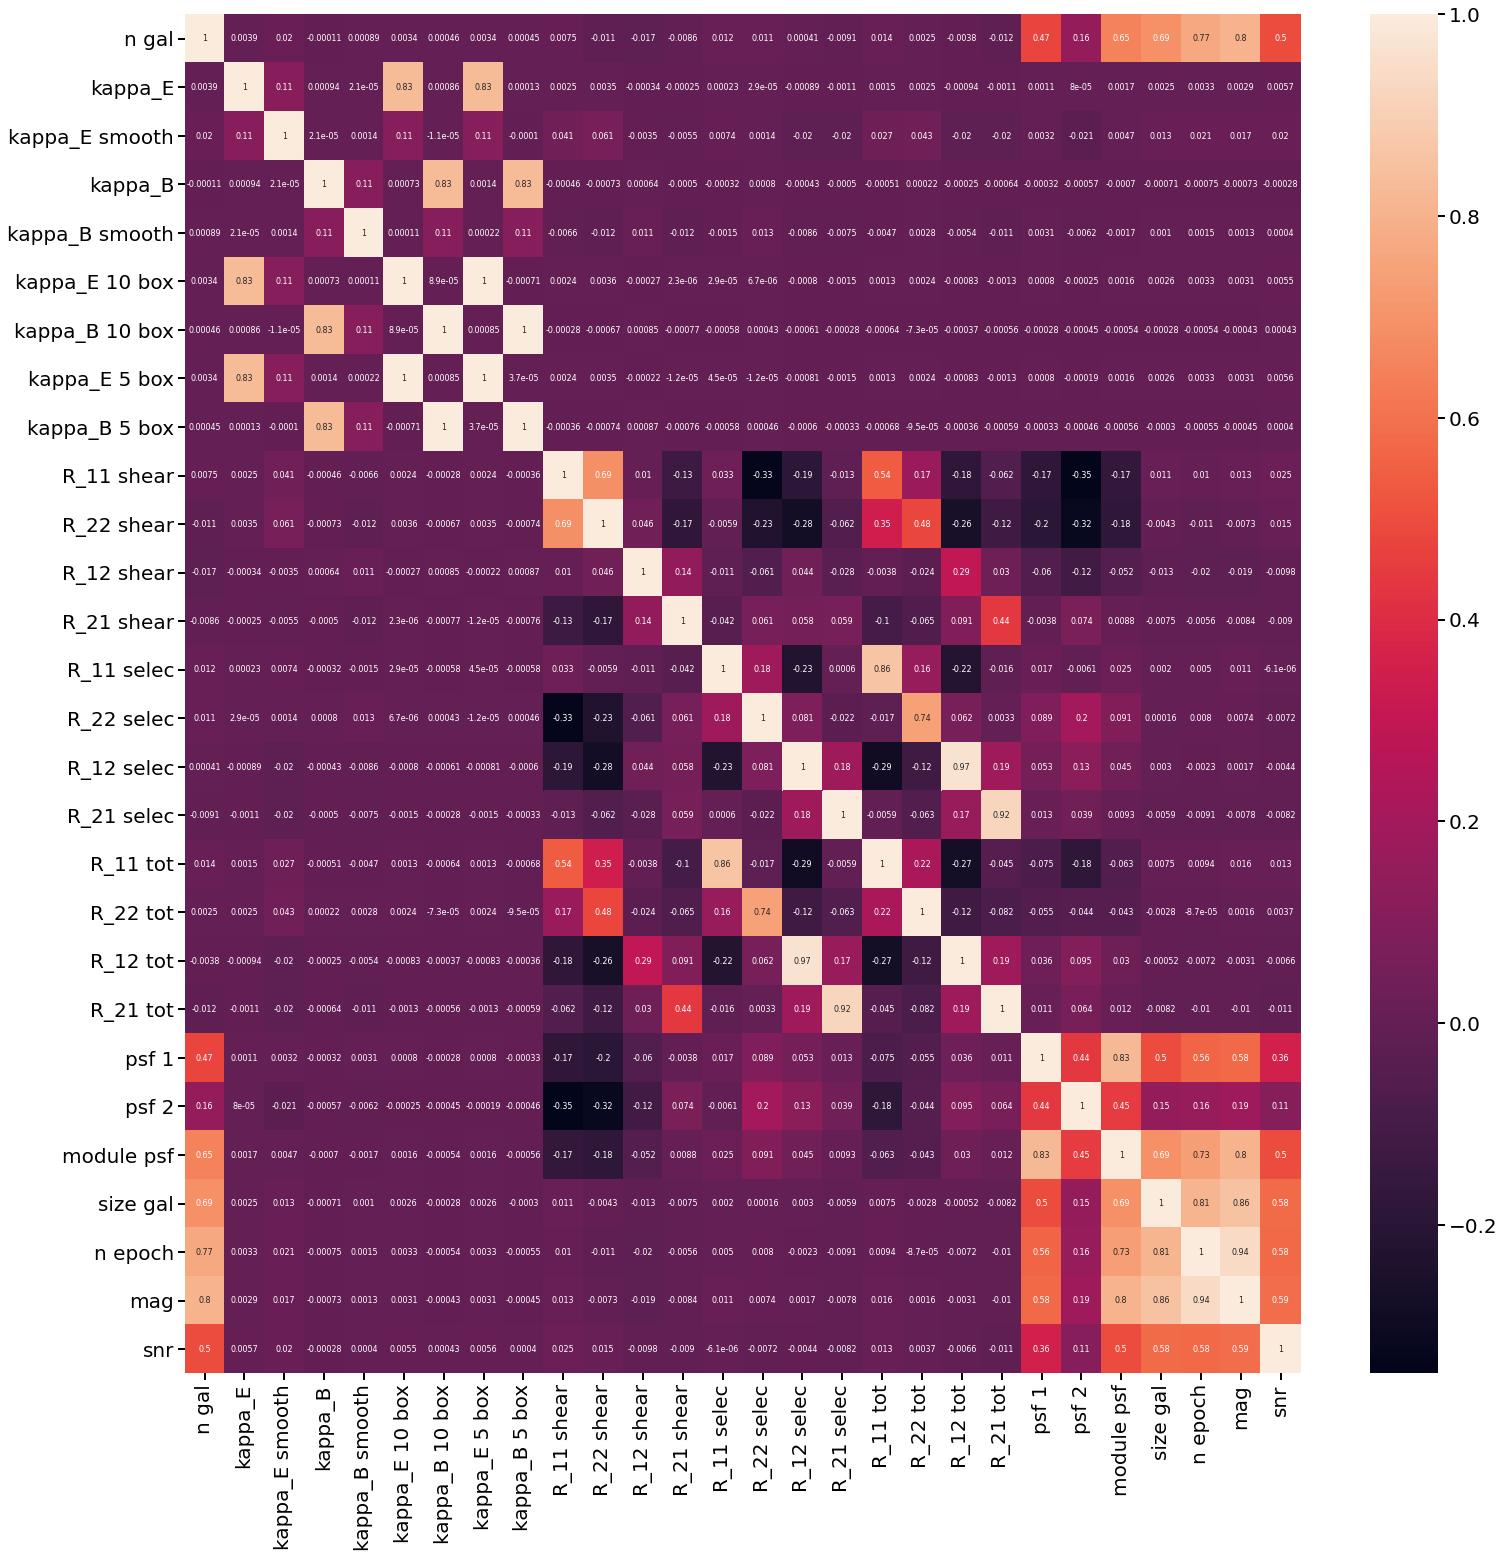

In [99]:
corrMatrix = df.corr()
plt.figure(figsize=(25,25))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":8})
plt.savefig('./W3/matrix_corr.jpg')
plt.show()

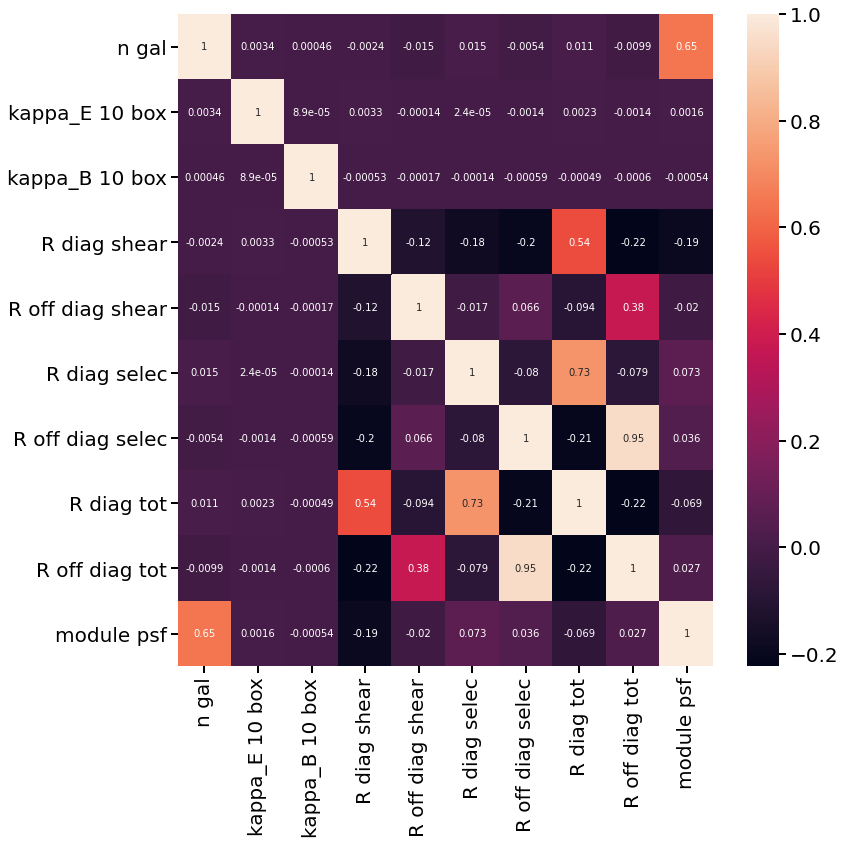

In [100]:
corrMatrix = df2.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":10})
plt.savefig('./W3/matrix_corr_reduite.jpg')
plt.show()

In [128]:
psf1map, psf2map = bin2d(xx, yy, npix=(14,7), v=(Psf1,Psf2))
psf = np.array([psf1map,psf2map])

ngaltot = bin2d(xx,yy,npix=(14,7))

module_psf_map, size_gal_map, nepoch_map, mag_map, snr_map = bin2d(xx, yy, npix=(14,7), v=(module_psf,size_gal,nepoch,mag,snr_win))

In [135]:
data = {'n gal': np.ravel(ngaltot),
        'R_11 shear': np.ravel(R_shear_deg[0,0,:,:]),
        'R_22 shear': np.ravel(R_shear_deg[1,1,:,:]),
        'R_12 shear': np.ravel(R_shear_deg[0,1,:,:]),
        'R_21 shear': np.ravel(R_shear_deg[1,0,:,:]),
        'R_11 selec': np.ravel(R_selec_deg[0,0,:,:]),
        'R_22 selec': np.ravel(R_selec_deg[1,1,:,:]),
        'R_12 selec': np.ravel(R_selec_deg[0,1,:,:]),
        'R_21 selec': np.ravel(R_selec_deg[1,0,:,:]),
        'R_11 shear 5': np.ravel(R_shear_2deg[0,0,:,:]),
        'R_22 shear 5': np.ravel(R_shear_2deg[1,1,:,:]),
        'R_12 shear 5': np.ravel(R_shear_2deg[0,1,:,:]),
        'R_21 shear 5': np.ravel(R_shear_2deg[1,0,:,:]),
        'R_11 selec 5': np.ravel(R_selec_2deg[0,0,:,:]),
        'R_22 selec 5': np.ravel(R_selec_2deg[1,1,:,:]),
        'R_12 selec 5': np.ravel(R_selec_2deg[0,1,:,:]),
        'R_21 selec 5': np.ravel(R_selec_2deg[1,0,:,:]),
        'psf 1': np.ravel(psf[0]),
        'psf 2': np.ravel(psf[1]),
        'module psf': np.ravel(module_psf_map),
        'size gal': np.ravel(size_gal_map),
        'n epoch': np.ravel(nepoch_map),
        'mag': np.ravel(mag_map),
        'snr': np.ravel(snr_map),
        'R diag shear': np.ravel((R_shear_deg[0,0,:,:]+R_shear_deg[1,1,:,:])/2),
        'R off diag shear': np.ravel((R_shear_deg[0,1,:,:]+R_shear_deg[1,0,:,:])/2),
        'R diag selec': np.ravel((R_selec_deg[0,0,:,:]+R_selec_deg[1,1,:,:])/2),
        'R off diag selec': np.ravel((R_selec_deg[0,1,:,:]+R_selec_deg[1,0,:,:])/2)
        }

In [137]:
df = pd.DataFrame(data,columns=['n gal','R_11 shear','R_22 shear','R_12 shear','R_21 shear','R_11 selec','R_22 selec',
                                'R_12 selec','R_21 selec',
                                'psf 1','psf 2','module psf','size gal','n epoch','mag','snr'])

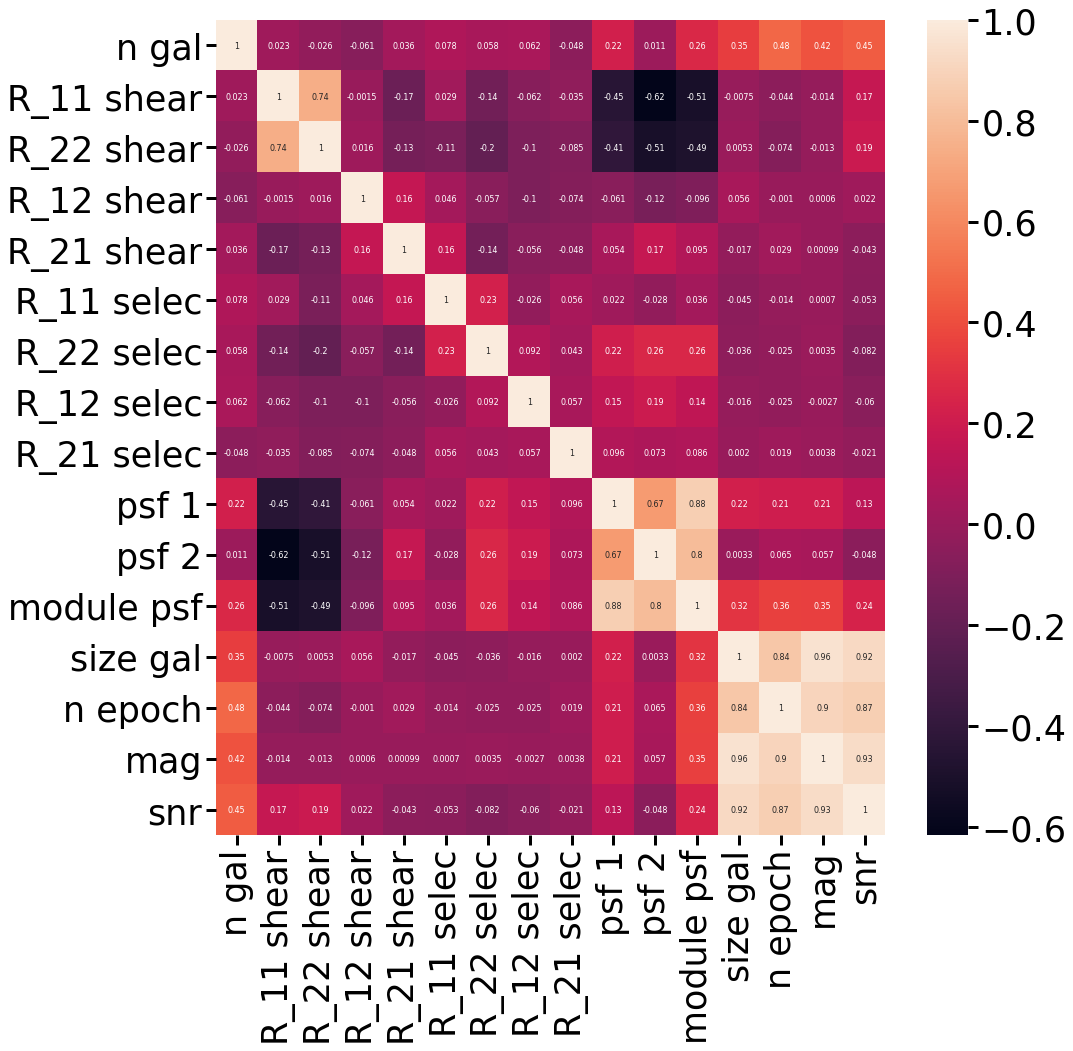

In [139]:
corrMatrix = df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corrMatrix, annot=True, annot_kws={"fontsize":8})
plt.show()

100%|██████████| 50/50 [00:02<00:00, 23.20it/s]


c 0.8358893316930034
(0.014014665975075329, 0.9765383346486011)


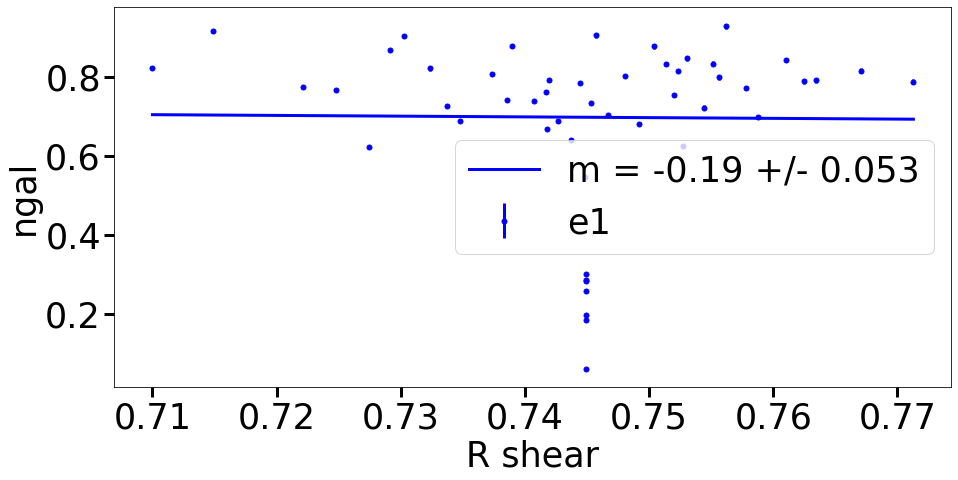

In [101]:
psf_e_corr2(np.ravel(ngaltot),np.ravel((Rshear_metacal_10box[0,0,:,:]+Rshear_metacal_10box[1,1,:,:])/2),
            'ngal_Rshear','R shear','ngal', weights=None,n_bin=50,save_plot=False)

In [102]:
Rselec_diag = np.ravel((Rselec_metacal_10box[0,0,:,:]+Rselec_metacal_10box[1,1,:,:])/2)
#mask = np.ravel(mask_large)

In [103]:
#psf_e_corr2(np.ravel(ngaltot)[np.where(mask==1)],Rselec_diag[np.where(mask==1)],
            #'ngal_Rselec','R selec','ngal', weights=None,n_bin=100,save_plot=False)

100%|██████████| 100/100 [00:02<00:00, 42.93it/s]


c 0.8025824544073248
(0.04261648810824353, 1.142835046243633)


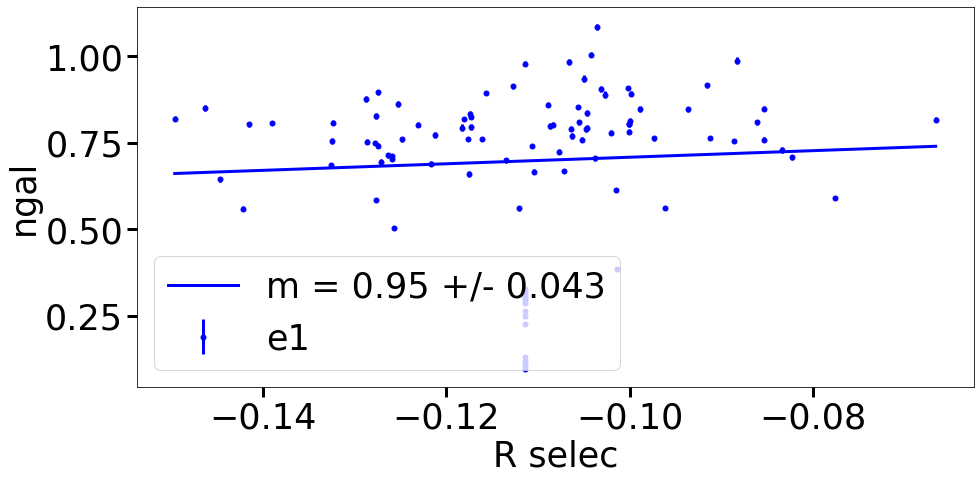

In [104]:
psf_e_corr2(np.ravel(ngaltot),Rselec_diag,
            'ngal_Rselec','R selec','ngal', weights=None,n_bin=100,save_plot=False)

100%|██████████| 50/50 [00:02<00:00, 21.57it/s]


c 0.04925079896494893
(0.6015358886315646, 0.6734602491040813)


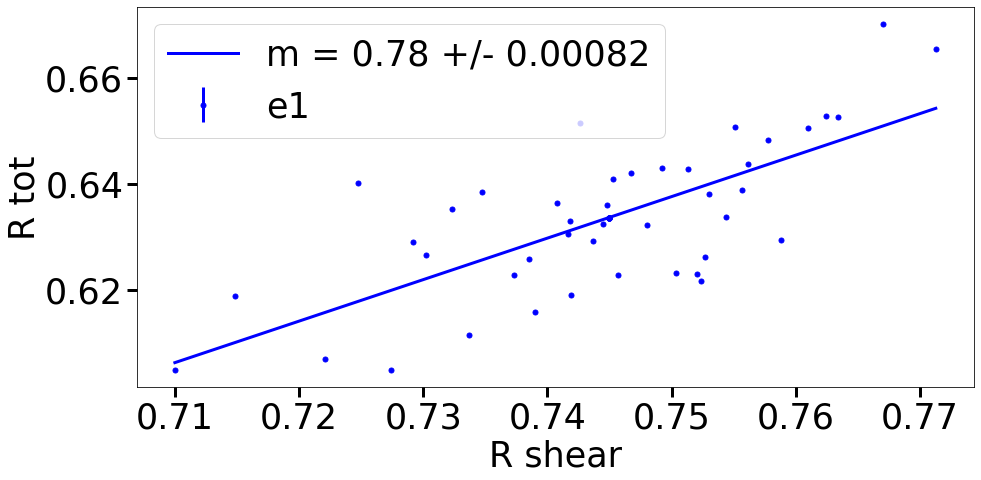

In [105]:
psf_e_corr2(np.ravel((Rtot_metacal_10box[0,0,:,:]+Rtot_metacal_10box[1,1,:,:])/2),np.ravel((Rshear_metacal_10box[0,0,:,:]+Rshear_metacal_10box[1,1,:,:])/2),
            'Rtot_Rshear','R shear','R tot', weights=None,n_bin=50,save_plot=False)

100%|██████████| 50/50 [00:02<00:00, 21.94it/s]


c 0.7289733986649707
(0.5796507146982995, 0.6712925783575024)


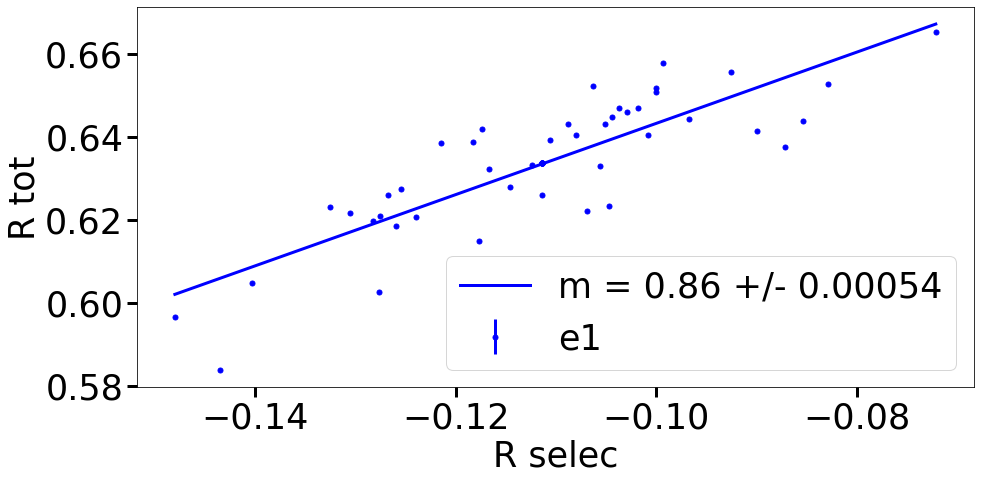

In [106]:
psf_e_corr2(np.ravel((Rtot_metacal_10box[0,0,:,:]+Rtot_metacal_10box[1,1,:,:])/2),np.ravel((Rselec_metacal_10box[0,0,:,:]+Rselec_metacal_10box[1,1,:,:])/2),
            'Rtot_Rselec','R selec','R tot', weights=None,n_bin=50,save_plot=False)

In [ ]:
n_gal_ngmix = len(g_ngmix[0])
d_gal_ngmix = n_gal_ngmix / tot_area
print("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2".format(n_gal_ngmix, d_gal_ngmix))
stat_file.write("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2\n".format(n_gal_ngmix, d_gal_ngmix))

In [ ]:
plt.figure(figsize=(30, 30))
plt.hexbin(ra_ngmix, dec_ngmix, gridsize=1000)
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title("Galaxy number count")
plt.xlabel("Ra (Deg)")
plt.ylabel("Dec (Deg)")
plt.savefig(plot_dir + 'galaxy_number_count_ngmix.png')

In [ ]:
ra_all = dd['XWIN_WORLD']
dec_all = dd['YWIN_WORLD']
plt.figure(figsize=(30, 30))
plt.hexbin(ra_all, dec_all, gridsize=100)
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title("All objects")
plt.xlabel("Ra (Deg)")
dummy = plt.ylabel("Dec (Deg)")

#### Galsim

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['NGMIX_FLUX_NOSHEAR'][m_gal_ngmix]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_ngmix], 500, range=(0,200), histtype='step', density=True, label='flux snr ngmix')
plt.hist(dd['SNR_WIN'][m_gal_ngmix], 500, range=(0,200), histtype='step', density=True, label='SEx snr ngmix')
plt.vlines(x=10, ymax=plt.ylim()[1], ymin=0, linestyles='--', colors='k', label='cut : 10')
plt.legend()
plt.xlabel('SNR')
plt.ylabel('frequency')
plt.title('SNR cut')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['SNR_WIN'][m_gal_galsim], 500, range=(0,200), histtype='step', density=True, label='SEx snr galsim')
plt.vlines(x=10, ymax=plt.ylim()[1], ymin=0, linestyles='--', colors='k', label='cut : 10')
plt.legend()
plt.xlabel('SNR')
plt.ylabel('frequency')
dummy = plt.title('SNR cut')

In [ ]:
gal_metacal_galsim = metacal(dd, m_gal_galsim, prefix='GALSIM')

In [ ]:
g_galsim = np.array([gal_metacal_galsim.ns['g1'][gal_metacal_galsim.mask_dict['ns']], gal_metacal_galsim.ns['g2'][gal_metacal_galsim.mask_dict['ns']]])
g_corr_galsim = np.linalg.inv(gal_metacal_galsim.R).dot(g_galsim)
w_galsim = gal_metacal_galsim.ns['w'][gal_metacal_galsim.mask_dict['ns']]
ra_galsim = dd['XWIN_WORLD'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
dec_galsim = dd['YWIN_WORLD'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
mag_galsim = dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
#snr_galsim = dd['NGMIX_FLUX_NOSHEAR'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]

In [ ]:
n_gal_galsim = len(g_galsim[0])
n_tiles = 214 #len(list(set(dd['TILE_ID'])))
area_tiles = 0.25
area_deg = n_tiles*area_tiles
tot_area = area_deg*3600
d_gal_galsim = n_gal_galsim / tot_area
print("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2".format(n_gal_galsim, d_gal_galsim))
stat_file.write("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2\n".format(n_gal_galsim, d_gal_galsim))

In [ ]:
plt.figure(figsize=(30, 30))
plt.hexbin(ra_galsim, dec_galsim, gridsize=1000)
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title("Galaxy number count")
plt.xlabel("Ra (Deg)")
plt.ylabel("Dec (Deg)")
plt.savefig(plot_dir + 'galaxy_number_count_galsim.png')

### Compile metacal for stars   
Masking : Flags == 0   &   SNR > 10   &   SNR < 500

#### Ngmix

In [ ]:
star_metacal_ngmix = metacal(dd[ind_star], m_star_ngmix, masking_type='star')

In [ ]:
n_star = len(star_metacal_ngmix.ns['g1'][star_metacal_ngmix.mask_dict['ns']])
tot_area = area_deg*3600
d_star = n_star / tot_area
print("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2".format(n_star, d_star, d_star*3600))
dummy = stat_file.write("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2\n".format(n_star, d_star, d_star*3600))

#### Galsim

In [ ]:
star_metacal_galsim = metacal(dd[ind_star], m_star_galsim, masking_type='star')

In [ ]:
n_star = len(star_metacal_galsim.ns['g1'][star_metacal_galsim.mask_dict['ns']])
tot_area = area_deg*3600
d_star = n_star / tot_area
print("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2".format(n_star, d_star, d_star*3600))
stat_file.write("Final number of stars : {}\nStar density : {:.2f}    star/arcmin^2\n               {:.2f} star/deg^2\n".format(n_star, d_star, d_star*3600))

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(gal_metacal_ngmix.R_shear[0,0], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='blue', label='$R11_{gal}$')
plt.hist(gal_metacal_ngmix.R_shear[1,1], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='red', label='$R22_{gal}$')
plt.hist(star_metacal_ngmix.R_shear[0,0,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='blue', label='$R11_{star}$')
plt.hist(star_metacal_ngmix.R_shear[1,1,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='red', label='$R22_{star}$')
plt.legend()
plt.xlabel('$R_{ii}$')
plt.ylabel('Nb')
plt.title('Response matrix ngmix')
plt.savefig(plot_dir + 'response_matrix_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(gal_metacal_galsim.R_shear[0,0], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='blue', label='$R11_{gal}$')
plt.hist(gal_metacal_galsim.R_shear[1,1], 500, range=(-3,3), histtype='step', density=True, linestyle="-", linewidth=2, color='red', label='$R22_{gal}$')
plt.hist(star_metacal_galsim.R_shear[0,0,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='blue', label='$R11_{star}$')
plt.hist(star_metacal_galsim.R_shear[1,1,:], 500, histtype='step', range=(-3,3), density=True, linestyle=":", linewidth=2, color='red', label='$R22_{star}$')
plt.legend()
plt.xlabel('$R_{ii}$')
plt.ylabel('Nb')
plt.title('Response matrix galsim')
plt.savefig(plot_dir + 'response_matrix_galsim.png')

### Galaxy response

#### Ngmix

In [ ]:
print('Galaxy total response matrix ngmix : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]'.format(gal_metacal_ngmix.R[0,0], gal_metacal_ngmix.R[0,1], gal_metacal_ngmix.R[1,0], gal_metacal_ngmix.R[1,1]))
dummy = stat_file.write('Galaxy total response matrix ngmix : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]\n'.format(gal_metacal_ngmix.R[0,0], gal_metacal_ngmix.R[0,1], gal_metacal_ngmix.R[1,0], gal_metacal_ngmix.R[1,1]))

In [ ]:
print('Galaxy selection response matrix ngmix : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]'.format(gal_metacal_ngmix.R_selection[0,0], gal_metacal_ngmix.R_selection[0,1], gal_metacal_ngmix.R_selection[1,0], gal_metacal_ngmix.R_selection[1,1]))
dummy = stat_file.write('Galaxy selection response matrix ngmix : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]\n'.format(gal_metacal_ngmix.R_selection[0,0], gal_metacal_ngmix.R_selection[0,1], gal_metacal_ngmix.R_selection[1,0], gal_metacal_ngmix.R_selection[1,1]))

In [ ]:
R_shear = np.mean(gal_metacal_ngmix.R_shear, 2)
print(R_shear)
print(gal_metacal_ngmix.R_selection)
R_sum = R_shear + gal_metacal_ngmix.R_selection
print(R_sum)

In [ ]:
print(np.shape(gal_metacal_ngmix.R_selection))

#### Galsim

In [ ]:
print('Galaxy total response matrix galsim : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]'.format(gal_metacal_galsim.R[0,0], gal_metacal_galsim.R[0,1], gal_metacal_galsim.R[1,0], gal_metacal_galsim.R[1,1]))
stat_file.write('Galaxy total response matrix galsim : [[{:.2f}    {:.2e}]\n                                [{:.2e}    {:.2f}]]\n'.format(gal_metacal_galsim.R[0,0], gal_metacal_galsim.R[0,1], gal_metacal_galsim.R[1,0], gal_metacal_galsim.R[1,1]))

In [ ]:
print('Galaxy selection response matrix galsim : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]'.format(gal_metacal_galsim.R_selection[0,0], gal_metacal_galsim.R_selection[0,1], gal_metacal_galsim.R_selection[1,0], gal_metacal_galsim.R_selection[1,1]))
stat_file.write('Galaxy selection response matrix galsim : [[{:.3f}    {:.2e}]\n                                    [{:.2e}    {:.3f}]]\n'.format(gal_metacal_galsim.R_selection[0,0], gal_metacal_galsim.R_selection[0,1], gal_metacal_galsim.R_selection[1,0], gal_metacal_galsim.R_selection[1,1]))

### Star response

In [ ]:
print('Star total response matrix ngmix : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]'.format(star_metacal_ngmix.R[0,0], star_metacal_ngmix.R[0,1], star_metacal_ngmix.R[1,0], star_metacal_ngmix.R[1,1]))
stat_file.write('Star total response matrix ngmix : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]\n'.format(star_metacal_ngmix.R[0,0], star_metacal_ngmix.R[0,1], star_metacal_ngmix.R[1,0], star_metacal_ngmix.R[1,1]))

In [ ]:
print('Star total response matrix galsim : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]'.format(star_metacal_galsim.R[0,0], star_metacal_galsim.R[0,1], star_metacal_galsim.R[1,0], star_metacal_galsim.R[1,1]))
stat_file.write('Star total response matrix galsim : [[{:.2f}     {:.2e}]\n                              [{:.2e}    {:.2f}]]\n'.format(star_metacal_galsim.R[0,0], star_metacal_galsim.R[0,1], star_metacal_galsim.R[1,0], star_metacal_galsim.R[1,1]))

In [ ]:
# The following creates an eror, star_response not found
#print('Star selection response matrix : [[{:.2e}    {:.2e}]\n                                  [{:.2e}    {:.2e}]]'.format(star_metacal.R_selection[0,0], star_metacal.R_selection[0,1], star_metacal.R_selection[1,0], star_metacal.R_selection[1,1]))
#stat_file.write('Star selection response matrix : [[{:.2e}    {:.2e}]\n                                  [{:.2e}    {:.2e}]]\n'.format(star_metacal.R_selection[0,0], star_metacal.R_selection[0,1], star_metacal.R_selection[1,0], star_metacal.R_selection[1,1]))

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(g_corr_ngmix[0], 500, weights=w_ngmix, histtype='step', density=True, label="$e_{1}$")
plt.hist(g_corr_ngmix[1], 500, weights=w_ngmix, histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{\\rm gal}$ distribution ngmix")
plt.savefig(plot_dir + 'e_gal_distribution_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(g_corr_galsim[0], 500, weights=w_galsim, histtype='step', density=True, label="$e_{1}$")
plt.hist(g_corr_galsim[1], 500, weights=w_galsim, histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{\\rm gal}$ distribution galsim")
plt.savefig(plot_dir + 'e_gal_distribution.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(star_metacal_ngmix.ns['g1'][star_metacal_ngmix.mask_dict['ns']], 500, weights=star_metacal_ngmix.ns['w'][star_metacal_ngmix.mask_dict['ns']], histtype='step', density=True, label="$e_{1}$")
plt.hist(star_metacal_ngmix.ns['g2'][star_metacal_ngmix.mask_dict['ns']], 500, weights=star_metacal_ngmix.ns['w'][star_metacal_ngmix.mask_dict['ns']], histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{star}$ distribution")
plt.savefig(plot_dir + 'e_star_distribution.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(star_metacal_galsim.ns['g1'][star_metacal_galsim.mask_dict['ns']], 500, weights=star_metacal_galsim.ns['w'][star_metacal_galsim.mask_dict['ns']], histtype='step', density=True, label="$e_{1}$")
plt.hist(star_metacal_galsim.ns['g2'][star_metacal_galsim.mask_dict['ns']], 500, weights=star_metacal_galsim.ns['w'][star_metacal_galsim.mask_dict['ns']], histtype='step', density=True, label="$e_{2}$")
plt.legend()
plt.xlabel('$e_{i}$')
plt.ylabel('Nb')
plt.title("$e_{star}$ distribution")
plt.savefig(plot_dir + 'e_star_distribution_galsim.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 500)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_ngmix.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 500)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_galsim.png')

In [ ]:
plt.figure(figsize=(30,20))
plt.hist(dd['MAG_AUTO'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 500, weights=w_ngmix, histtype='step', density=True)
plt.hist(dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 500, histtype='step', density=True)
plt.xlabel('Mag')
plt.ylabel('Nb')
plt.title('Magnitude distribution')
plt.savefig(plot_dir + 'gal_mag_distribution_both.png')

## Additive bias

#### Ngmix

In [ ]:
c1_ngmix, err_c1_ngmix = jackknif_weighted_average(g_corr_ngmix[0], w_ngmix, remove_size=0.05, n_realization=500)
print('Additive bias c1 : {:.3e} +/- {:.3e}'.format(c1_ngmix, err_c1_ngmix))
stat_file.write('Additive bias c1 : {:.3e} +/- {:.3e}\n'.format(c1_ngmix, err_c1_ngmix))

In [ ]:
c2_ngmix, err_c2_ngmix = jackknif_weighted_average(g_corr_ngmix[1], w_ngmix, remove_size=0.05, n_realization=500)
print('Additive bias c2 : {:.3e} +/- {:.3e}'.format(c2_ngmix, err_c2_ngmix))
stat_file.write('Additive bias c2 : {:.3e} +/- {:.3e}\n'.format(c2_ngmix, err_c2_ngmix))

#### Galsim

In [ ]:
c1_galsim, err_c1_galsim = jackknif_weighted_average(g_corr_galsim[0], np.ones_like(w_galsim), remove_size=0.05, n_realization=500)
print('Additive bias c1 : {:.3e} +/- {:.3e}'.format(c1_galsim, err_c1_galsim))
stat_file.write('Additive bias c1 : {:.3e} +/- {:.3e}\n'.format(c1_galsim, err_c1_galsim))

In [ ]:
c2_galsim, err_c2_galsim = jackknif_weighted_average(g_corr_galsim[1], np.ones_like(w_galsim), remove_size=0.05, n_realization=500)
print('Additive bias c2 : {:.3e} +/- {:.3e}'.format(c2_galsim, err_c2_galsim))
stat_file.write('Additive bias c2 : {:.3e} +/- {:.3e}\n'.format(c2_galsim, err_c2_galsim))

In [ ]:
sig_eps = np.sqrt(np.var(g_corr_ngmix[0]) + np.var(g_corr_ngmix[1]))
print('Ellipticity dispersion (complex; mean per component): {:.3f}; {:.3f}'.format(sig_eps, sig_eps /  np.sqrt(2)))

## PSF leakage

### Binning leakage

Use PSF ellipticity at galaxy positions.

#### Ngmix

In [ ]:
psf_e_corr(g_corr_ngmix[0]-c1_ngmix, 
           g_corr_ngmix[1]-c2_ngmix,
           dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 
           dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']], 
           dd['NGMIX_T_PSFo_NOSHEAR'][m_gal_ngmix][gal_metacal_ngmix.mask_dict['ns']]/1.17741*2.355, 
           weights=w_ngmix, 
           n_bin=30,
           save_plot=True,
           plot_dir=plot_dir + '/psf_leak_ngmix/')

In [ ]:
psf_e_corr(g_corr_galsim[0]-c1_galsim, 
           g_corr_galsim[1]-c2_galsim,
           dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 
           dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,1][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']], 
           dd['GALSIM_PSF_SIGMA_ORIGINAL_PSF'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]*2.355*0.187, 
           weights=np.ones_like(w_galsim), 
           n_bin=30,
           save_plot=True,
           plot_dir=plot_dir + '/psf_leak_galsim/')

### Alpha leakage

Use PSF ellipticity at star positions.

Equation alpha leakage :
$
    \alpha = \frac{\xi_{+}^{gp} - \langle e_{gal} \rangle^{*} \langle e_{PSF} \rangle}{\xi_{+}^{pp} - |\langle e_{PSF} \rangle|^{2}}
$    
With $g$: galaxy and $p$: PSF.

#### Ngmix

In [ ]:
r_corr_gp_ngmix = xi_star_gal_tc(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1])
r_corr_pp_ngmix = xi_star_gal_tc(ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1], np.ones_like(g_star_psf_ngmix[0]), ra_star_ngmix, dec_star_ngmix, g_star_psf_ngmix[0], g_star_psf_ngmix[1])

In [ ]:
complex_gal_ngmix = np.average(g_corr_ngmix[0]-c1_ngmix, weights=w_ngmix) + np.average(g_corr_ngmix[1]-c2_ngmix, weights=w_ngmix)*1j
complex_psf_ngmix = np.mean(g_star_psf_ngmix[0]) + np.mean(g_star_psf_ngmix[1])*1j

In [ ]:
alpha_leak_ngmix = (r_corr_gp_ngmix.xip - np.real(np.conj(complex_gal_ngmix)*complex_psf_ngmix))/(r_corr_pp_ngmix.xip - np.abs(complex_psf_ngmix)**2.)

In [ ]:
sig_alpha_leak_ngmix = np.abs(alpha_leak_ngmix)*np.sqrt((np.sqrt(r_corr_gp_ngmix.varxip)/r_corr_gp_ngmix.xip)**2. + (np.sqrt(r_corr_pp_ngmix.varxip)/r_corr_pp_ngmix.xip)**2.)

In [ ]:
alpha_leak_mean_ngmix = np.average(alpha_leak_ngmix, weights=1/sig_alpha_leak_ngmix**2.)
print('All sales weitghed average alpha : {}'.format(alpha_leak_mean_ngmix))
stat_file.write('All scales weitghed average alpha : {}\n'.format(alpha_leak_mean_ngmix))

In [ ]:
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['font.size'] = 35
mpl.rcParams['xtick.minor.size'] = 7
mpl.rcParams['ytick.minor.size'] = 7
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
mpl.rcParams['boxplot.flierprops.markersize'] = 12
mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
mpl.rcParams['boxplot.capprops.linewidth'] = 2.


mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

plt.figure(figsize=(30,20))

plt.errorbar(r_corr_gp_ngmix.meanr, alpha_leak_ngmix, yerr=sig_alpha_leak_ngmix, label=r'$\alpha$')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.5,plt.xlim()[1]-30)
#plt.ylim(-0.5,0.5)
plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\alpha$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.savefig(plot_dir + 'alpha_leakage_ngmix.png')

## $\xi^{sys}$

Use PSF ellipticity at star positions.

Equation alpha leakage :
$
\xi^{sys} = \frac{\xi_{\pm}^{gp^{2}}}{\xi_{\pm}^{pp}}
$    
With $g$: galaxy and $p$: PSF.

In [ ]:
C_sys_p_ngmix = r_corr_gp_ngmix.xip**2/r_corr_pp_ngmix.xip
C_sys_m_ngmix = r_corr_gp_ngmix.xim**2/r_corr_pp_ngmix.xim
#C_sys_var = np.sqrt(r_corr_gp.varxi**2./r_corr_pp.varxi)
C_sys_std_p_ngmix = np.abs(C_sys_p_ngmix) * np.sqrt((((2*r_corr_gp_ngmix.xip**2.*np.sqrt(r_corr_gp_ngmix.varxip))/r_corr_gp_ngmix.xip)/r_corr_gp_ngmix.xip**2.)**2. + (np.sqrt(r_corr_pp_ngmix.varxip)/r_corr_pp_ngmix.xip)**2.)
C_sys_std_m_ngmix = np.abs(C_sys_m_ngmix) * np.sqrt((((2*r_corr_gp_ngmix.xim**2.*np.sqrt(r_corr_gp_ngmix.varxim))/r_corr_gp_ngmix.xim)/r_corr_gp_ngmix.xim**2.)**2. + (np.sqrt(r_corr_pp_ngmix.varxim)/r_corr_pp_ngmix.xim)**2.)

## Redshift distribution

In [ ]:
nz_base = 'nz.CFHTLenSmatched.W3'
nz_ext = 'txt'
nz_date = '202012'
nz_version = 'v1'
nz_name = '{}_{}_{}.{}'.format(nz_base, nz_date, nz_version, nz_ext)
source = 'vos:cfis/cosmostat/cosmology/redshifts/{}'.format(nz_name)

download(source, nz_name, verbose=True)

In [ ]:
z, nz = np.loadtxt(nz_name, unpack=True)

#theta = np.logspace(np.log10(2), np.log10(2e2), 20)

Om = 0.3153
sig8 = 0.8111
ns = 0.9649
Ob = 0.0493
h = 0.6736
xi_p_planck, xi_m_planck = get_theo_xi(r_corr_gp_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
plt.errorbar(r_corr_gp_ngmix.meanr, C_sys_p_ngmix, yerr=C_sys_std_p_ngmix, label=r'$\xi_{+}^{sys}$')
plt.plot(r_corr_gp_ngmix.meanr, xi_p_planck, ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_ngmix.meanr, xi_m_planck, ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
plt.errorbar(r_corr_gp_ngmix.meanr*(1.02), C_sys_m_ngmix, yerr=C_sys_std_m_ngmix, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ngmix.png')

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
#plt.errorbar(r_corr_gp.meanr, C_sys_p, yerr=C_sys_std_p, label=r'$\xi_{+}^{sys}$')
#plt.plot(r_corr_gp.meanr, f_theo_p_p(r_corr_gp.meanr), ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.plot(r_corr_gp.meanr, f_theo_m_p(r_corr_gp.meanr), ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_ngmix.meanr, C_sys_p_ngmix/xi_p_planck, color=color[0], label=r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
#plt.errorbar(r_corr_gp.meanr*(1.02), C_sys_m, yerr=C_sys_std_m, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ratio_ngmix.png')

#### Galsim

In [ ]:
r_corr_gp_galsim = xi_star_gal_tc(ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim), ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1])
r_corr_pp_galsim = xi_star_gal_tc(ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1], np.ones_like(g_star_psf_galsim[0]), ra_star_galsim, dec_star_galsim, g_star_psf_galsim[0], g_star_psf_galsim[1])

In [ ]:
complex_gal_galsim = np.average(g_corr_galsim[0]-c1_galsim, weights=np.ones_like(w_galsim)) + np.average(g_corr_galsim[1]-c2_galsim, weights=np.ones_like(w_galsim))*1j
complex_psf_galsim = np.mean(g_star_psf_galsim[0]) + np.mean(g_star_psf_galsim[1])*1j

In [ ]:
alpha_leak_galsim = (r_corr_gp_galsim.xip - np.real(np.conj(complex_gal_galsim)*complex_psf_galsim))/(r_corr_pp_galsim.xip - np.abs(complex_psf_galsim)**2.)

In [ ]:
sig_alpha_leak_galsim = np.abs(alpha_leak_galsim)*np.sqrt((np.sqrt(r_corr_gp_galsim.varxip)/r_corr_gp_galsim.xip)**2. + (np.sqrt(r_corr_pp_galsim.varxip)/r_corr_pp_galsim.xip)**2.)

In [ ]:
alpha_leak_mean_galsim = np.average(alpha_leak_galsim, weights=1/sig_alpha_leak_galsim**2.)
print('All sales weitghed average alpha : {}'.format(alpha_leak_mean_galsim))
stat_file.write('All sales weitghed average alpha : {}\n'.format(alpha_leak_mean_galsim))

In [ ]:
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['font.size'] = 35
mpl.rcParams['xtick.minor.size'] = 7
mpl.rcParams['ytick.minor.size'] = 7
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
mpl.rcParams['boxplot.flierprops.markersize'] = 12
mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
mpl.rcParams['boxplot.capprops.linewidth'] = 2.


mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

plt.figure(figsize=(30,20))

plt.errorbar(r_corr_gp_galsim.meanr, alpha_leak_galsim, yerr=sig_alpha_leak_galsim, label=r'$\alpha$')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.5,plt.xlim()[1]-30)
#plt.ylim(-0.5,0.5)
plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\alpha$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.savefig(plot_dir + 'alpha_leakage_galsim.png')

In [ ]:
C_sys_p_galsim = r_corr_gp_galsim.xip**2/r_corr_pp_galsim.xip
C_sys_m_galsim = r_corr_gp_galsim.xim**2/r_corr_pp_galsim.xim
#C_sys_var = np.sqrt(r_corr_gp.varxi**2./r_corr_pp.varxi)
C_sys_std_p_galsim = np.abs(C_sys_p_galsim) * np.sqrt((((2*r_corr_gp_galsim.xip**2.*np.sqrt(r_corr_gp_galsim.varxip))/r_corr_gp_galsim.xip)/r_corr_gp_galsim.xip**2.)**2. + (np.sqrt(r_corr_pp_galsim.varxip)/r_corr_pp_galsim.xip)**2.)
C_sys_std_m_galsim = np.abs(C_sys_m_galsim) * np.sqrt((((2*r_corr_gp_galsim.xim**2.*np.sqrt(r_corr_gp_galsim.varxim))/r_corr_gp_galsim.xim)/r_corr_gp_galsim.xim**2.)**2. + (np.sqrt(r_corr_pp_galsim.varxim)/r_corr_pp_galsim.xim)**2.)

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
plt.errorbar(r_corr_gp_galsim.meanr, C_sys_p_galsim, yerr=C_sys_std_p_galsim, label=r'$\xi_{+}^{sys}$')
plt.plot(r_corr_gp_galsim.meanr, xi_p_planck, ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_galsim.meanr, xi_m_planck, ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
plt.errorbar(r_corr_gp_galsim.meanr*(1.02), C_sys_m_galsim, yerr=C_sys_std_m_galsim, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_galsim.png')

In [ ]:
#mpl.rcParams['lines.linewidth'] = 3
#mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['font.size'] = 35
#mpl.rcParams['xtick.minor.size'] = 7
#mpl.rcParams['ytick.minor.size'] = 7
#mpl.rcParams['xtick.major.size'] = 10
#mpl.rcParams['ytick.major.size'] = 10
#mpl.rcParams['xtick.major.width'] = 3
#mpl.rcParams['ytick.major.width'] = 3
#mpl.rcParams['boxplot.boxprops.linewidth'] = 2.
#mpl.rcParams['boxplot.medianprops.linewidth'] = 2.
#mpl.rcParams['boxplot.flierprops.markersize'] = 12
#mpl.rcParams['boxplot.whiskerprops.linewidth'] = 2.
#mpl.rcParams['boxplot.capprops.linewidth'] = 2.
#mpl.rcParams['axes.xmargin'] = mpl.rcParamsDefault['axes.xmargin']

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(30,20))
#plt.errorbar(r_corr_gp.meanr, C_sys_p, yerr=C_sys_std_p, label=r'$\xi_{+}^{sys}$')
#plt.plot(r_corr_gp.meanr, f_theo_p_p(r_corr_gp.meanr), ':', color=color[0], label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.plot(r_corr_gp.meanr, f_theo_m_p(r_corr_gp.meanr), ':', color=color[1], label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$')
plt.plot(r_corr_gp_galsim.meanr, C_sys_p_galsim/xi_p_planck, color=color[0], label=r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')

#ind_neg = np.where(C_sys_m <= 0)[0]
#ind_pos = np.where(C_sys_m > 0)[0]
#plt.errorbar(res.meanr[ind_neg]+0.05*res.meanr[ind_neg], np.abs(C_sys_m[ind_neg]), yerr=C_sys_std_m[ind_neg], linestyle='--', color=color[1], label=r'$\xi_{-}^{sys}$')
#plt.errorbar(res.meanr[[ind_neg[-1], ind_pos[0]]]+0.05*res.meanr[[ind_neg[-1], ind_pos[0]]], np.abs(C_sys_m[[ind_neg[-1], ind_pos[0]]]), yerr=C_sys_std_m[[ind_neg[-1], ind_pos[0]]], linestyle='--', color=color[1])
#plt.errorbar(res.meanr[ind_pos]+0.05*res.meanr[ind_pos], C_sys_m[ind_pos], yerr=C_sys_std_m[ind_pos], color=color[1], linestyle='-')
#plt.errorbar(r_corr_gp.meanr*(1.02), C_sys_m, yerr=C_sys_std_m, label=r'$\xi_{-}^{sys}$')

plt.xscale('log')
#plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-30)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\pm}/\xi_{+}^{\Lambda\mathrm{CDM}}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_sys_ratio_galsim.png')

## Write catalog

In [ ]:
# TODO: move this function to the python script.

def write_catalog_bias(output_path, ra, dec, g1, g2, w, mag, snr,
                       R, R_select, c1, c2, c1_err, c2_err, alpha_leak,
                       g1_uncal=None, g2_uncal=None, R_11=None,
                       R_22=None, R_12=None, R_21=None):
    """
    """

    # Data HDU
    c_ra = fits.Column(name='ra', array=ra, format='D', unit='deg')
    c_dec = fits.Column(name='dec', array=dec, format='D', unit='deg')
    c_g1 = fits.Column(name='g1', array=g1, format='D')
    c_g2 = fits.Column(name='g2', array=g2, format='D')
    c_w = fits.Column(name='w', array=w, format='D')
    c_mag = fits.Column(name='mag', array=mag, format='D')
    c_snr = fits.Column(name='snr', array=snr, format='D')
    cols = [c_ra, c_dec, c_g1, c_g2, c_w, c_mag, c_snr]

    for x, name in zip([g1_uncal, g2_uncal, R_11, R_22, R_12, R_21],
                       ['g1_uncal', 'g2_uncal', 'R_11', 'R_22', 'R_12', 'R_21']):
        if x is not None:
            cols.append(fits.Column(name=name, array=x, format='D'))

    table_hdu = fits.BinTableHDU.from_columns(cols)

    table_hdu.header['TTYPE3'] = ('g1', 'Reduced shear (a-b)/(a+b)')
    table_hdu.header['TTYPE4'] = ('g2', 'Reduced shear (a-b)/(a+b)')
    table_hdu.header['TTYPE5'] = ('w', 'Ellipticity weight')
    table_hdu.header['TTYPE6'] = ('mag', 'From SExtractor: MAG_AUTO')
    table_hdu.header['TTYPE7'] = ('snr', 'SNR computed on metacal noshear: flux/flux_std')
    
    ntype =  8
    for x in ([g1_uncal, g2_uncal], ['g1_uncal', 'g2_uncal']):
        if x is not None:
            table_hdu.header['TTYPE{}'.format(ntype)] = (name, 'uncalibrated reduced shear')
            ntype += 1
    for x, name in zip([R_11, R_22, R_12, R_21], ['R_11', 'R_22', 'R_12', 'R_21']):
        if x is not None:
            table_hdu.header['TTYPE{}'.format(ntype)] = (name, f'full response matrix {name}')
            ntype += 1

    # Primary HDU with information in header
    primary_header = fits.Header()

    primary_header['R'] = (r'<R>', r'Full response: <R> = <R_shear> + <R_select>')

    primary_header['R1_1'] = (R[0,0], 'Full response matrix')
    primary_header['R1_2'] = (R[0,1], 'Full response matrix')
    primary_header['R2_1'] = (R[1,0], 'Full response matrix')
    primary_header['R2_2'] = (R[1,1], 'Full response matrix')

    primary_header['RS'] = (r'<RS>', r'Selection response matrix: <R_select>')
    primary_header['RS1_1'] = (R_select[0,0], 'Selection response matrix')
    primary_header['RS1_2'] = (R_select[0,1], 'Selection response matrix')
    primary_header['RS2_1'] = (R_select[1,0], 'Selection response matrix')
    primary_header['RS2_2'] = (R_select[1,1], 'Selection response matrix')

    primary_header['g_corr'] = ('Apply correction', r'g_corr = R**(-1).g')

    primary_header['c'] = ('', 'Additive bias computed with JackKnife')
    primary_header['c1'] = (c1, 'Additive bias for g1')
    primary_header['c1_err'] = (c1_err, 'Standard deviation for c1')
    primary_header['c2'] = (c2, 'Additive bias for g2')
    primary_header['c2_err'] = (c2_err, 'Standard deviation for c2')

    primary_header['w'] = ('Ellipticity weight', r'1 / (2*sig_SN**2 + g1_var + g2_var)')
    primary_header['sig_SN'] = (0.34, 'Sigma_shape_noise')

    primary_header['alpha'] = (alpha_leak, 'PSF leakage alpha')

    primary_hdu = fits.PrimaryHDU(header=primary_header)

    # Final file
    hdu_list = fits.HDUList([primary_hdu, table_hdu])

    hdu_list.writeto(output_path, overwrite=True)


In [ ]:
out_name = 'shape_catalog_W3_MCCD_20210326.fits'

R = np.zeros_like(gal_metacal_ngmix.R_shear)
for i in (0,1):
    for j in (0, 1):
        R[i, j] = gal_metacal_ngmix.R_shear[i, j] + gal_metacal_ngmix.R_selection[i, j]

# Debug
alpha_leaka_mean_ngmix = 0
        
write_catalog_bias(out_name,
                   ra_ngmix, dec_ngmix,
                   g_corr_ngmix[0], g_corr_ngmix[1], w_ngmix,
                   mag_ngmix, snr_ngmix, 
                   gal_metacal_ngmix.R, gal_metacal_ngmix.R_selection,
                   c1_ngmix, c2_ngmix, err_c1_ngmix, err_c2_ngmix,
                   alpha_leaka_mean_ngmix,
                   g1_uncal=g_ngmix[0],g2_uncal=g_ngmix[1], 
                   R_11=R[0, 0], R_12=R[0, 1], R_21=R[1, 0], R_22=R[1, 1])

## Some cosmological calculations

### Ngmix

### Shear-Shear

In [ ]:
res_g_ngmix = xi_gal_gal_tc(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

##### Cosmo planck

In [ ]:
z, nz = np.loadtxt(nz_name, unpack=True)

Om = 0.3153
sig8 = 0.8111
ns = 0.9649
Ob = 0.0493
h = 0.6736
xi_p_planck, xi_m_planck = get_theo_xi(res_g_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

##### Cosmo DES

In [ ]:
Om = 0.295
S8 = 0.768
sig8 = S8 / ((Om/0.3)**0.5)
#sig8 = 0.8111
ns = 1.044
Ob = 0.0516
h = 0.672
xi_p_des, xi_m_des = get_theo_xi(res_g_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)

In [ ]:
pos_ind_gg = res_g_ngmix.xip >= 0
neg_ind_gg = res_g_ngmix.xip < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_ngmix.meanr[pos_ind_gg], res_g_ngmix.xip[pos_ind_gg], yerr=np.sqrt(res_g_ngmix.varxip[pos_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4, label=r'$\xi_{+}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_ngmix.meanr[neg_ind_gg], np.abs(res_g_ngmix.xip[neg_ind_gg]), yerr=np.sqrt(res_g_ngmix.varxip[neg_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4)#, label=r'$\xi_{+}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_ngmix.meanr, xi_p_planck, 'k:', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_ngmix.meanr, xi_p_des, 'k--', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.3,plt.xlim()[1]-0)

plt.xticks([2, 10, 100], labels=['2', '10', '100'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{+}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_+_shear_shear_ngmix.png')

In [ ]:
pos_ind_gg = res_g_ngmix.xim >= 0
neg_ind_gg = res_g_ngmix.xim < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_ngmix.meanr[pos_ind_gg], res_g_ngmix.xim[pos_ind_gg], yerr=np.sqrt(res_g_ngmix.varxim[pos_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4, label=r'$\xi_{-}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_ngmix.meanr[neg_ind_gg], np.abs(res_g_ngmix.xim[neg_ind_gg]), yerr=np.sqrt(res_g_ngmix.varxim[neg_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4)#, label=r'$\xi_{-}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_ngmix.meanr, xi_m_planck, 'k:', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_ngmix.meanr, xi_m_des, 'k--', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1])

plt.xticks([2, 10, 100], labels=['2', '10', '100'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{-}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_-_shear_shear_ngmix.png')

### Galsim

In [ ]:
res_g_galsim = xi_gal_gal_tc(ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim), ra_galsim, dec_galsim, g_corr_galsim[0]-c1_galsim, g_corr_galsim[1]-c2_galsim, np.ones_like(w_galsim))

In [ ]:
pos_ind_gg = res_g_galsim.xip >= 0
neg_ind_gg = res_g_galsim.xip < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_galsim.meanr[pos_ind_gg], res_g_galsim.xip[pos_ind_gg], yerr=np.sqrt(res_g_galsim.varxip[pos_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4, label=r'$\xi_{+}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_galsim.meanr[neg_ind_gg], np.abs(res_g_galsim.xip[neg_ind_gg]), yerr=np.sqrt(res_g_galsim.varxip[neg_ind_gg]), linestyle='', color=color[0], marker='x', capsize=4)#, label=r'$\xi_{+}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_galsim.meanr, xi_p_planck, 'k:', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_galsim.meanr, xi_p_des, 'k--', label=r'$\xi_{+}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1]-0)

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{+}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_+_shear_shear_galsim.png')

In [ ]:
pos_ind_gg = res_g_galsim.xim >= 0
neg_ind_gg = res_g_galsim.xim < 0

plt.figure(figsize=(15,10))

eb1 = plt.errorbar(res_g_galsim.meanr[pos_ind_gg], res_g_galsim.xim[pos_ind_gg], yerr=np.sqrt(res_g_galsim.varxim[pos_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4, label=r'$\xi_{-}$')
eb1[-1][0].set_linestyle('-')

eb2 = plt.errorbar(res_g_galsim.meanr[neg_ind_gg], np.abs(res_g_galsim.xim[neg_ind_gg]), yerr=np.sqrt(res_g_galsim.varxim[neg_ind_gg]), linestyle='', color=color[1], marker='o', markerfacecolor='none', capsize=4)#, label=r'$\xi_{-}$')
eb2[-1][0].set_linestyle(':')

plt.plot(res_g_galsim.meanr, xi_m_planck, 'k:', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ planck')
plt.plot(res_g_galsim.meanr, xi_m_des, 'k--', label=r'$\xi_{-}^{\Lambda\mathrm{CDM}}$ DESY1')

plt.xscale('log')
plt.yscale('log')
plt.xlim(plt.xlim()[0]+0.,plt.xlim()[1])

plt.xticks([2, 10, 200], labels=['2', '10', '200'])
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{-}$')
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.gca().yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: ("$10^{%d}$" % math.log(v,10)) ))
plt.legend()
plt.savefig(plot_dir + 'xi_-_shear_shear_galsim.png')

### Cluster lensing

#### Load Planck cluster catalog

In [ ]:
cluster_cat_name = 'HFI_PCCS_SZ-union_R2.08.fits.gz'
source = 'vos:cfis/cosmostat/cosmology/external/Planck/{}'.format(cluster_cat_name)
download(source, cluster_cat_name, verbose=True)

In [ ]:
cluster_cat = fits.getdata(cluster_cat_name)
m_good_cluster = (cluster_cat['MSZ'] != 0) & (cluster_cat['COSMO'] == True)
m_cluster_foot = get_mask_footprint_P3(cluster_cat['RA'][m_good_cluster], cluster_cat['DEC'][m_good_cluster])
sdss_cluster_cut = {'ra': cluster_cat['RA'][m_good_cluster][m_cluster_foot], 'dec':cluster_cat['DEC'][m_good_cluster][m_cluster_foot], 'z':cluster_cat['REDSHIFT'][m_good_cluster][m_cluster_foot], 'M':cluster_cat['MSZ'][m_good_cluster][m_cluster_foot]*1e14}
#sdss_cluster_cut = {'ra': cluster_cat['RA'][m_good_cluster][m_cluster_foot][1:2], 'dec':cluster_cat['DEC'][m_good_cluster][m_cluster_foot][1:2], 'z':cluster_cat['REDSHIFT'][m_good_cluster][m_cluster_foot][1:2], 'M':cluster_cat['MSZ'][m_good_cluster][m_cluster_foot][1:2]*1e14}

In [ ]:
plt.figure(figsize=(15,15))
plt.plot(ra_ngmix, dec_ngmix, '+')
plt.plot(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], '*')
for i in range(len(sdss_cluster_cut['ra'])):
    plt.text(sdss_cluster_cut['ra'][i], sdss_cluster_cut['dec'][i]+ 0.02 * (plt.ylim()[0] - plt.ylim()[1]), i, color='k', fontsize=10, ha='center', va='center')

In [ ]:
ind_cluster_keep = [2,4,5,6,7,8,9,10,11,13,14,15]
for key in sdss_cluster_cut.keys():
    sdss_cluster_cut[key] = sdss_cluster_cut[key][ind_cluster_keep]

In [ ]:
print('Number of clusters : {}'.format(len(sdss_cluster_cut['z'])))
stat_file.write('Number of clusters : {}\n'.format(len(sdss_cluster_cut['z'])))

In [ ]:
R_p, logR_p, gamT_p, gamX_p, gam_sig_p = gamma_T_tc(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

In [ ]:
gamT_p

In [ ]:


plt.figure(figsize=(30,20))
# plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label='gamma_T')
# plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)

errplot = plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label=r'$\gamma_{t}$ known clusters')
#plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)
plt.hlines(y=0, xmin=np.min(logR_p), xmax=np.max(logR_p), linestyles='dashed')
# plt.xscale('log')
plt.title(r'Lensing by clusters')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$log(\theta$) (arcmin)')
#plt.xticks(fontsize=20)
#plt.yticks(fontsize=20)

plt.gca().xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.5))
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.xlim(plt.xlim()[0]+0.3,plt.xlim()[1]-0.3)

plt.legend([errplot, Patch(facecolor='w', edgecolor='k')], [r'$\gamma_{t}$ known clusters', r'random positions'])
#plt.savefig('new_cat/cluster_profile_bp.png')

In [ ]:
stacked_gammaT_theo = np.zeros(15)
for m_clust, z_clust in tqdm(zip(sdss_cluster_cut['M'], sdss_cluster_cut['z']), total=len(sdss_cluster_cut['M'])):
    stacked_gammaT_theo += get_theo_gamT(m_clust, z_clust, z_source=0.68, theta=R_p, meanbin_z=z, nz=nz)

In [ ]:
plt.figure(figsize=(30,20))
# plt.errorbar(logR_p, gamT_p, yerr=gam_sig_p, capsize = 3, label='gamma_T')
# plt.boxplot(res[:,2,:], positions=logR_p, widths=0.2)

plt.errorbar(R_p, gamT_p, yerr=gam_sig_p, capsize = 3, label=r'Data')
plt.plot(R_p, stacked_gammaT_theo/len(sdss_cluster_cut['M']), label=r'Theoretical NFW profile')
plt.xscale('log')
plt.hlines(y=0, xmin=plt.xlim()[0], xmax=plt.xlim()[1], linestyles='dashed')
plt.xlim(plt.xlim()[0]+0.13,plt.xlim()[1]-17)
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\gamma_{t}$')
plt.legend()
plt.title('Stacked cluster profiles')
plt.savefig(plot_dir + 'all_clusters_profile.png')

In [ ]:
R_m, logR_m, gamT_m, gamX_m, gam_sig_m = gamma_T_tc(sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix)

In [ ]:
mean_z_clust = np.mean(sdss_cluster_cut['z'])
m_est, fitted_profile = get_theo_mass(mean_z_clust, R_m, gamT_m, gam_sig_m, 0.98, meanbin_z=z, nz=nz)

In [ ]:
print("Cluster mean redshift : {}".format(mean_z_clust))
print("Estimated mass : {:.3E}".format(m_est))
print('"True" mass : {:.3E}'.format(np.mean(sdss_cluster_cut['M'])*0.7))
stat_file.write("Cluster mean redshift : {}\n".format(mean_z_clust))
stat_file.write("Estimated mass : {:.3E}\n".format(m_est))
stat_file.write('"True" mass : {:.3E}\n'.format(np.mean(sdss_cluster_cut['M'])*0.7))

In [ ]:
plt.figure(figsize=(30,20))
plt.errorbar(R_m, gamT_m, yerr=gam_sig_m, label=r'Data')
plt.plot(R_m, fitted_profile, label=r'Best fit NFW profile')
plt.hlines(y=0, xmin=np.min(R_m), xmax=np.max(R_m), linestyles='dashed')
plt.xscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\gamma_{t}$')
plt.legend()
plt.title('Mass recovery (best fit)')

### Mass maps

#### Full mass map

In [ ]:
#from lenspack.utils import bin2d
#from lenspack.geometry.projections.gnom import radec2xy

In [ ]:
xx, yy = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), ra_ngmix, dec_ngmix)

In [ ]:
help(radec2xy)

In [ ]:
#e1map, e2map = bin2d(correct_ra2(ra[m_test], dec[m_test]), dec[m_test], v=(g_corr[0][m_test]-c1, g_corr[1][m_test]-c2), w=w[m_test], npix=2048, verbose=True)

In [ ]:
e1map, e2map = bin2d(xx, yy, v=(g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix), w=w_ngmix, npix=4096, verbose=True)

In [ ]:
kappaE, kappaB = ks93(e1map, -e2map)

In [ ]:
from scipy.ndimage.filters import gaussian_filter as gf

In [ ]:
xx_cluster, yy_cluster = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), sdss_cluster_cut['ra'], sdss_cluster_cut['dec'])
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaE, 16))
vminE, vmaxE = plt.gci().get_clim()
x_cluster = (xx_cluster - -0.24970972516329504) / 0.00011016574322916806
y_cluster = (yy_cluster - -0.12938850035423424) / 7.312034604994855e-05
dy = 0.02
plt.plot(x_cluster, y_cluster, 'k+')
for i in range(len(sdss_cluster_cut['z'])):
    plt.text(x_cluster[i], y_cluster[i] + dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['z'][i],3), color='k', fontsize=10, ha='center', va='center')
    plt.text(x_cluster[i], y_cluster[i] - dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['M'][i]/1e14, 2), color='k', fontsize=10, ha='center', va='center')
plt.colorbar()

loc, labels = plt.xticks()
plt.xticks(loc[1:-1], labels=np.round(np.arange(ra_ngmix.min(), ra_ngmix.max(), step=(ra_ngmix.max()-ra_ngmix.min())/len(loc[1:-1])), 1))
loc, labels = plt.yticks()
plt.yticks(loc[1:-1], labels=np.round(np.arange(dec_ngmix.min(), dec_ngmix.max(), step=(dec_ngmix.max()-dec_ngmix.min())/len(loc[1:-1])), 1))
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('Ra (deg)')
plt.ylabel('Dec (deg)')
plt.title('$\kappa_{E}$')
plt.savefig(plot_dir + 'mass_map_planck_cluster_E.png')

In [ ]:
xx_cluster, yy_cluster = radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), sdss_cluster_cut['ra'], sdss_cluster_cut['dec'])
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaB, 16), vmin=vminE, vmax=vmaxE)
x_cluster = (xx_cluster - -0.24970972516329504) / 0.00011016574322916806
y_cluster = (yy_cluster - -0.12938850035423424) / 7.312034604994855e-05
dy = 0.02
plt.plot(x_cluster, y_cluster, 'k+')
for i in range(len(sdss_cluster_cut['z'])):
    plt.text(x_cluster[i], y_cluster[i] + dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['z'][i],3), color='k', fontsize=10, ha='center', va='center')
    plt.text(x_cluster[i], y_cluster[i] - dy * (plt.ylim()[0] - plt.ylim()[1]), round(sdss_cluster_cut['M'][i]/1e14, 2), color='k', fontsize=10, ha='center', va='center')
plt.colorbar()

loc, labels = plt.xticks()
plt.xticks(loc[1:-1], labels=np.round(np.arange(ra_ngmix.min(), ra_ngmix.max(), step=(ra_ngmix.max()-ra_ngmix.min())/len(loc[1:-1])), 1))
loc, labels = plt.yticks()
plt.yticks(loc[1:-1], labels=np.round(np.arange(dec_ngmix.min(), dec_ngmix.max(), step=(dec_ngmix.max()-dec_ngmix.min())/len(loc[1:-1])), 1))
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('Ra (deg)')
plt.ylabel('Dec (deg)')
plt.title('$\kappa_{B}$')
plt.savefig(plot_dir + 'mass_map_planck_cluster_B.png')

#### Stacked mass map

In [ ]:
radius = 5

In [ ]:
res_stack_mm = stack_mm3(ra_ngmix, dec_ngmix, g_corr_ngmix[0]-c1_ngmix, g_corr_ngmix[1]-c2_ngmix, w_ngmix, sdss_cluster_cut['ra'], sdss_cluster_cut['dec'], sdss_cluster_cut['z'], radius=radius, n_match=1000000)

In [ ]:
len(res_stack_mm[0])

In [ ]:
plt.figure(figsize=(20,20))
plt.hexbin(res_stack_mm[0], res_stack_mm[1], gridsize=100, cmap='gist_stern')
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title('Density plot')

In [ ]:
#e1map, e2map = bin2d(correct_ra2(res_stack_mm[0], res_stack_mm[1]), res_stack_mm[1], v=(res_stack_mm[2], res_stack_mm[2]), w=res_stack_mm[4], npix=1024, verbose=True)
e1map_stack, e2map_stack = bin2d(res_stack_mm[0], res_stack_mm[1], v=(res_stack_mm[2], -res_stack_mm[3]), w=res_stack_mm[4], npix=2048, verbose=True)

In [ ]:
kappaE_stack, kappaB_stack = ks93(e1map_stack, e2map_stack)

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaE_stack, 32))
vminEs, vmaxEs = plt.gci().get_clim()
plt.plot(1023, 1023, '+')
n_ticks = 4
plt.xticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
plt.yticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
cbar = plt.colorbar()
cbar.set_label('$\kappa_{E}$')
plt.xlabel('Mpc')
plt.ylabel('Mpc')
plt.title(r'$\kappa_{E}$ map')
plt.savefig(plot_dir + 'cluster_mass_map_E.png')

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(gf(kappaB_stack, 32), vmin=vminEs, vmax=vmaxEs)
plt.plot(1023, 1023, '+')
n_ticks = 4
plt.xticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
plt.yticks(np.arange(0, 2048+2048/n_ticks, step=2048/n_ticks), labels=np.round(np.arange(-radius, radius+radius*2/n_ticks, step=radius*2/n_ticks), 1))
cbar = plt.colorbar()
cbar.set_label('$\kappa_{B}$')
plt.xlabel('Mpc')
plt.ylabel('Mpc')
plt.title(r'$\kappa_{B}$ map')
plt.savefig(plot_dir + 'cluster_mass_map_B.png')

#### Close stat file

In [ ]:
stat_file.close()